<a href="https://colab.research.google.com/github/LM-Ham/TravelTide_CustomerSegmentation_Python/blob/main/traveltide_rewards_segmentation_LeonMay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive  # import des google-drive-moduls
drive.mount("/content/drive")  # einbinden von google drive in die colab-session

import os  # import der os-bibliothek für dateipfade

PROJECT_DIR = "/content/drive/MyDrive/TravelTide_MasteryProject"  # definition des projektordners in google drive
os.listdir(PROJECT_DIR)  # anzeigen der dateien im projektordner

Mounted at /content/drive


['session_level_cohort.csv',
 'processed',
 'traveltide_rewards_segmentation_LeonMay.ipynb',
 'ExecutiveEssay_TravelTide.pdf',
 'TravelTide.pptx']

In [2]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

CSV_FILENAME = "session_level_cohort.csv"  # definition des csv-dateinamens im projektordner
csv_path = f"{PROJECT_DIR}/{CSV_FILENAME}"  # zusammensetzen des vollständigen dateipfads zur csv

df = pd.read_csv(csv_path)  # laden der csv in einen pandas-dataframe
df.shape  # ausgabe der dimensionen (zeilen, spalten)

(49211, 41)

In [3]:
def normalize_bool(series):  # definition einer funktion zur normalisierung bool-ähnlicher werte
    s = series.copy()  # erstellen einer kopie der eingangsspalte
    s = s.astype(str).str.strip().str.lower()  # normalisierung durch string-konvertierung und kleinschreibung
    true_vals = {"true", "t", "1", "yes", "y"}  # definition der wahr-werte als menge
    false_vals = {"false", "f", "0", "no", "n"}  # definition der falsch-werte als menge
    s = np.where(s.isin(true_vals), True, np.where(s.isin(false_vals), False, pd.NA))  # abbildung auf boolean oder fehlend
    return pd.Series(s)  # rückgabe als pandas-series

bool_cols = ["flight_discount", "hotel_discount", "flight_booked", "hotel_booked", "cancellation"]  # definition der bool-spaltenliste
for col in bool_cols:  # iteration über die bool-spalten
    df[col] = normalize_bool(df[col])  # normalisierung der bool-spalte auf True/False/NA

num_cols = [  # definition der numerischen spaltenliste
    "page_clicks",
    "flight_discount_amount",
    "hotel_discount_amount",
    "flight_seats",
    "flight_checked_bags",
    "flight_base_fare_usd",
    "hotel_nights",
    "hotel_rooms",
    "hotel_per_room_usd",
    "session_duration_sec",
]  # abschließen der numerischen spaltenliste

for col in num_cols:  # iteration über die numerischen spalten
    df[col] = pd.to_numeric(df[col], errors="coerce")  # konvertierung auf numeric mit coercion bei fehlern

In [4]:
total_rows = len(df)  # berechnung der anzahl zeilen
total_users = df["user_id"].nunique()  # berechnung der anzahl eindeutiger user_id
total_sessions = df["session_id"].nunique()  # berechnung der anzahl eindeutiger session_id

summary_base = pd.DataFrame({  # erzeugung einer basis-zusammenfassung als dataframe
    "metric": ["rows", "unique_users", "unique_sessions"],  # definition der metrik-namen
    "value": [total_rows, total_users, total_sessions],  # definition der metrik-werte
})  # abschließen der basis-zusammenfassung

summary_base  # ausgabe der basis-zusammenfassung

,metric,value
0,rows,49211
1,unique_users,5998
2,unique_sessions,49211


In [5]:
hotel_row_present = df["hotel_name"].notna()  # indikator für vorhandenen hotel-record
hotel_nights_null = df["hotel_nights"].isna()  # indikator für fehlende nights-werte
hotel_nights_zero = df["hotel_nights"].eq(0)  # indikator für nights==0
hotel_nights_negative = df["hotel_nights"].lt(0)  # indikator für nights<0

hotel_qc = pd.DataFrame({  # erzeugung einer hotel-qc-tabelle
    "metric": [  # definition der metrik-namen
        "sessions_total",
        "sessions_with_hotel_row",
        "sessions_without_hotel_row",
        "sessions_hotel_nights_null",
        "sessions_hotel_nights_zero",
        "sessions_hotel_nights_negative",
    ],  # abschließen der metrik-namen
    "count": [  # definition der zählwerte
        int(len(df)),
        int(hotel_row_present.sum()),
        int((~hotel_row_present).sum()),
        int(hotel_nights_null.sum()),
        int(hotel_nights_zero.sum()),
        int(hotel_nights_negative.sum()),
    ],  # abschließen der zählwerte
})  # abschließen der hotel-qc-tabelle

hotel_qc["pct_of_sessions"] = (hotel_qc["count"] / len(df) * 100).round(2)  # berechnung der anteile bezogen auf alle sessions
hotel_qc  # ausgabe der hotel-qc-tabelle

,metric,count,pct_of_sessions
0,sessions_total,49211,100.00
1,sessions_with_hotel_row,14726,29.92
2,sessions_without_hotel_row,34485,70.08
3,sessions_hotel_nights_null,34485,70.08
4,sessions_hotel_nights_zero,1228,2.50
5,sessions_hotel_nights_negative,107,0.22


In [6]:
flight_booked_true = df["flight_booked"].eq(True)  # indikator für flight_booked==true
hotel_booked_true = df["hotel_booked"].eq(True)  # indikator für hotel_booked==true

flight_price_missing_when_booked = flight_booked_true & df["flight_base_fare_usd"].isna()  # indikator für gebuchten flug mit fehlendem preis
hotel_price_missing_when_booked = hotel_booked_true & df["hotel_per_room_usd"].isna()  # indikator für gebuchtes hotel mit fehlendem preis

count_flight_booked = int(flight_booked_true.sum())  # zählung flight_booked==true
count_hotel_booked = int(hotel_booked_true.sum())  # zählung hotel_booked==true
count_flight_missing = int(flight_price_missing_when_booked.sum())  # zählung fehlender flight-preise bei booking
count_hotel_missing = int(hotel_price_missing_when_booked.sum())  # zählung fehlender hotel-preise bei booking

pct_flight_missing = round(100.0 * count_flight_missing / max(count_flight_booked, 1), 2)  # berechnung des anteils fehlender flight-preise
pct_hotel_missing = round(100.0 * count_hotel_missing / max(count_hotel_booked, 1), 2)  # berechnung des anteils fehlender hotel-preise

booking_price_qc = pd.DataFrame({  # erzeugung einer qc-tabelle zu fehlenden preisen
    "metric": [  # definition der metrik-namen
        "sessions_flight_booked_true",
        "sessions_flight_booked_true_price_missing",
        "pct_flight_price_missing_of_flight_booked",
        "sessions_hotel_booked_true",
        "sessions_hotel_booked_true_price_missing",
        "pct_hotel_price_missing_of_hotel_booked",
    ],  # abschließen der metrik-namen
    "value": [  # definition der metrik-werte
        count_flight_booked,
        count_flight_missing,
        pct_flight_missing,
        count_hotel_booked,
        count_hotel_missing,
        pct_hotel_missing,
    ],  # abschließen der metrik-werte
})  # abschließen der qc-tabelle

booking_price_qc  # ausgabe der qc-tabelle

,metric,value
0,sessions_flight_booked_true,14320.00
1,sessions_flight_booked_true_price_missing,50.00
2,pct_flight_price_missing_of_flight_booked,0.35
3,sessions_hotel_booked_true,14919.00
4,sessions_hotel_booked_true_price_missing,193.00
5,pct_hotel_price_missing_of_hotel_booked,1.29


In [7]:
min_page_clicks = int(df["page_clicks"].min())  # berechnung des minimalen page_clicks-werts
count_clicks_lt_2 = int(df["page_clicks"].lt(2).sum())  # zählung der sessions mit page_clicks<2
pct_clicks_lt_2 = round(100.0 * count_clicks_lt_2 / len(df), 2)  # berechnung des anteils sessions mit page_clicks<2

page_clicks_qc = pd.DataFrame({  # erzeugung einer qc-tabelle zu page_clicks
    "metric": ["min_page_clicks", "sessions_page_clicks_lt_2", "pct_sessions_page_clicks_lt_2"],  # definition der metrik-namen
    "value": [min_page_clicks, count_clicks_lt_2, pct_clicks_lt_2],  # definition der metrik-werte
})  # abschließen der qc-tabelle

page_clicks_qc  # ausgabe der qc-tabelle

,metric,value
0,min_page_clicks,1.00
1,sessions_page_clicks_lt_2,424.00
2,pct_sessions_page_clicks_lt_2,0.86


In [8]:
import os  # import der os-bibliothek
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

df = df.copy()  # erstellen einer arbeitskopie des dataframes

df["hotel_check_in_time"] = pd.to_datetime(df["hotel_check_in_time"], errors="coerce")  # konvertierung check-in zu datetime
df["hotel_check_out_time"] = pd.to_datetime(df["hotel_check_out_time"], errors="coerce")  # konvertierung check-out zu datetime

hotel_row_present = df["hotel_name"].notna()  # indikator für vorhandenen hotel-record
hotel_nights_anomalous = hotel_row_present & df["hotel_nights"].notna() & df["hotel_nights"].le(0)  # indikator für nights<=0 bei vorhandenem hotel-record

checkin_date = df["hotel_check_in_time"].dt.date  # extraktion des check-in-datums
checkout_date = df["hotel_check_out_time"].dt.date  # extraktion des check-out-datums
inferred_nights = (pd.to_datetime(checkout_date) - pd.to_datetime(checkin_date)).dt.days  # berechnung der inferred_nights als tagesdifferenz

df["hotel_nights_inferred"] = inferred_nights  # speichern der inferred_nights in einer spalte

df["hotel_nights_clean"] = df["hotel_nights"]  # initialisierung der bereinigten nights-spalte mit originalwerten
fixable_nights = hotel_nights_anomalous & df["hotel_nights_inferred"].gt(0)  # indikator für korrigierbare nights-werte
df.loc[fixable_nights, "hotel_nights_clean"] = df.loc[fixable_nights, "hotel_nights_inferred"]  # ersetzen anomalem nights durch inferred_nights
df.loc[hotel_nights_anomalous & ~fixable_nights, "hotel_nights_clean"] = np.nan  # setzen nicht-korrigierbarer anomalien auf missing

df["flight_price_missing_when_booked"] = df["flight_booked"].eq(True) & df["flight_base_fare_usd"].isna()  # indikator für fehlenden flugpreis trotz booking
df["hotel_price_missing_when_booked"] = df["hotel_booked"].eq(True) & df["hotel_per_room_usd"].isna()  # indikator für fehlenden hotelpreis trotz booking

df["low_click_session"] = df["page_clicks"].lt(2)  # indikator für sessions mit page_clicks<2

PROCESSED_DIR = f"{PROJECT_DIR}/processed"  # definition des processed-ordners im projektverzeichnis
os.makedirs(PROCESSED_DIR, exist_ok=True)  # erstellen des processed-ordners falls nicht vorhanden

processed_path = f"{PROCESSED_DIR}/session_level_cohort_cleaned.csv"  # definition des dateipfads für die bereinigte csv
df.to_csv(processed_path, index=False)  # speichern des bereinigten dataframes als csv
processed_path  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/session_level_cohort_cleaned.csv'

In [9]:
total_sessions = len(df)  # berechnung der anzahl sessions

count_anomalous_before = int((hotel_row_present & df["hotel_nights"].notna() & df["hotel_nights"].le(0)).sum())  # zählung anomalien im original
count_fixed = int((df["hotel_nights"].notna() & df["hotel_nights"].le(0) & df["hotel_nights_clean"].gt(0)).sum())  # zählung erfolgreich korrigierter fälle
count_anomalous_remaining = int((hotel_row_present & df["hotel_nights_clean"].notna() & df["hotel_nights_clean"].le(0)).sum())  # zählung verbleibender nights<=0 nach bereinigung

post_fix_qc = pd.DataFrame({  # erzeugung einer qc-tabelle nach bereinigung
    "metric": ["anomalies_before", "fixed_to_positive", "anomalies_remaining"],  # definition der metrik-namen
    "count": [count_anomalous_before, count_fixed, count_anomalous_remaining],  # definition der zählwerte
})  # abschließen der qc-tabelle

post_fix_qc["pct_of_sessions"] = (post_fix_qc["count"] / total_sessions * 100).round(2)  # berechnung der anteile bezogen auf alle sessions
post_fix_qc  # ausgabe der qc-tabelle

,metric,count,pct_of_sessions
0,anomalies_before,1335,2.71
1,fixed_to_positive,891,1.81
2,anomalies_remaining,0,0.00


In [10]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

df = df.copy()  # erstellen einer arbeitskopie des dataframes

outlier_cols = [  # definition der spaltenliste für outlier-vergleich
    "session_duration_sec",
    "page_clicks",
    "flight_base_fare_usd",
    "hotel_per_room_usd",
    "flight_seats",
    "flight_checked_bags",
    "hotel_nights_clean",
    "hotel_rooms",
]  # abschließen der spaltenliste

q_low = 0.01  # definition des unteren quantils
q_high = 0.99  # definition des oberen quantils

rows = []  # initialisierung einer liste für vergleichszeilen

for col in outlier_cols:  # iteration über die outlier-spalten
    s = df[col].dropna()  # auswahl der nicht-missing werte der spalte
    n = int(s.shape[0])  # berechnung der anzahl nicht-missing werte

    q01 = float(s.quantile(q_low))  # berechnung des 1%-quantils
    q99 = float(s.quantile(q_high))  # berechnung des 99%-quantils

    below_q = int((s < q01).sum())  # zählung der werte unterhalb q01
    above_q = int((s > q99).sum())  # zählung der werte oberhalb q99
    pct_q_capped = round(100.0 * (below_q + above_q) / max(n, 1), 2)  # berechnung des anteils außerhalb der quantile

    q1 = float(s.quantile(0.25))  # berechnung des 25%-quantils
    q3 = float(s.quantile(0.75))  # berechnung des 75%-quantils
    iqr = float(q3 - q1)  # berechnung des interquartilsabstands

    iqr_low = float(q1 - 1.5 * iqr)  # berechnung der unteren iqr-grenze (1.5*IQR)
    iqr_high = float(q3 + 1.5 * iqr)  # berechnung der oberen iqr-grenze (1.5*IQR)

    below_iqr = int((s < iqr_low).sum())  # zählung der werte unterhalb der iqr-grenze
    above_iqr = int((s > iqr_high).sum())  # zählung der werte oberhalb der iqr-grenze
    pct_iqr_outliers = round(100.0 * (below_iqr + above_iqr) / max(n, 1), 2)  # berechnung des anteils außerhalb der iqr-grenzen

    rows.append({  # speichern der vergleichskennzahlen in einer zeile
        "column": col,
        "non_null": n,
        "q01": q01,
        "q99": q99,
        "pct_outside_q01_q99": pct_q_capped,
        "iqr_q1": q1,
        "iqr_q3": q3,
        "iqr": iqr,
        "iqr_low": iqr_low,
        "iqr_high": iqr_high,
        "pct_outside_iqr_1_5": pct_iqr_outliers,
    })  # abschließen der zeile

compare_df = pd.DataFrame(rows)  # erzeugung des vergleichs-dataframes
compare_df  # ausgabe des vergleichs-dataframes

,column,non_null,q01,q99,pct_outside_q01_q99,iqr_q1,iqr_q3,iqr,iqr_low,iqr_high,pct_outside_iqr_1_5
0,session_duration_sec,49211,14.00,2757.361398,1.90,45.0000,162.0000,117.0,-130.5000,337.5000,4.74
1,page_clicks,49211,2.00,116.000000,1.85,6.0000,22.0000,16.0,-18.0000,46.0000,4.27
2,flight_base_fare_usd,14270,24.66,4280.567500,2.00,200.4325,600.6325,400.2,-399.8675,1200.9325,6.08
3,hotel_per_room_usd,14726,38.00,620.750000,1.97,99.0000,222.0000,123.0,-85.5000,406.5000,4.62
4,flight_seats,14270,1.00,4.000000,0.36,1.0000,1.0000,0.0,1.0000,1.0000,15.52
5,flight_checked_bags,14270,0.00,3.000000,0.48,0.0000,1.0000,1.0,-1.5000,2.5000,1.18
6,hotel_nights_clean,14282,1.00,18.000000,0.85,1.0000,5.0000,4.0,-5.0000,11.0000,4.91
7,hotel_rooms,14726,1.00,3.000000,0.63,1.0000,1.0000,0.0,1.0000,1.0000,15.46


In [11]:
compare_df.sort_values("pct_outside_iqr_1_5", ascending=False)  # sortierung nach iqr-outlier-anteil

,column,non_null,q01,q99,pct_outside_q01_q99,iqr_q1,iqr_q3,iqr,iqr_low,iqr_high,pct_outside_iqr_1_5
4,flight_seats,14270,1.00,4.000000,0.36,1.0000,1.0000,0.0,1.0000,1.0000,15.52
7,hotel_rooms,14726,1.00,3.000000,0.63,1.0000,1.0000,0.0,1.0000,1.0000,15.46
2,flight_base_fare_usd,14270,24.66,4280.567500,2.00,200.4325,600.6325,400.2,-399.8675,1200.9325,6.08
6,hotel_nights_clean,14282,1.00,18.000000,0.85,1.0000,5.0000,4.0,-5.0000,11.0000,4.91
0,session_duration_sec,49211,14.00,2757.361398,1.90,45.0000,162.0000,117.0,-130.5000,337.5000,4.74
3,hotel_per_room_usd,14726,38.00,620.750000,1.97,99.0000,222.0000,123.0,-85.5000,406.5000,4.62
1,page_clicks,49211,2.00,116.000000,1.85,6.0000,22.0000,16.0,-18.0000,46.0000,4.27
5,flight_checked_bags,14270,0.00,3.000000,0.48,0.0000,1.0000,1.0,-1.5000,2.5000,1.18


In [12]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

df = df.copy()  # erstellen einer arbeitskopie des dataframes

outlier_cols = [  # definition der spaltenliste für winsorizing
    "session_duration_sec",
    "page_clicks",
    "flight_base_fare_usd",
    "hotel_per_room_usd",
    "flight_seats",
    "flight_checked_bags",
    "hotel_nights_clean",
    "hotel_rooms",
]  # abschließen der spaltenliste

q_low = 0.01  # definition des unteren quantils
q_high = 0.99  # definition des oberen quantils

bounds = {}  # initialisierung eines dictionaries für quantilgrenzen

for col in outlier_cols:  # iteration über die outlier-spalten
    s = df[col].dropna()  # auswahl der nicht-missing werte der spalte
    bounds[col] = (float(s.quantile(q_low)), float(s.quantile(q_high)))  # speichern der quantilgrenzen je spalte

winsor_report = []  # initialisierung einer liste für winsorizing-statistiken

for col in outlier_cols:  # iteration über die outlier-spalten
    low_val, high_val = bounds[col]  # auslesen der quantilgrenzen
    below_mask = df[col].notna() & df[col].lt(low_val)  # indikator für werte unterhalb der unteren grenze
    above_mask = df[col].notna() & df[col].gt(high_val)  # indikator für werte oberhalb der oberen grenze
    count_below = int(below_mask.sum())  # zählung der werte unterhalb der grenze
    count_above = int(above_mask.sum())  # zählung der werte oberhalb der grenze
    non_null = int(df[col].notna().sum())  # zählung der nicht-missing werte
    df[f"{col}_winsor"] = df[col].clip(lower=low_val, upper=high_val)  # erstellen der winsorisierten spalte
    winsor_report.append({  # speichern der report-zeile
        "column": col,
        "q01": low_val,
        "q99": high_val,
        "non_null": non_null,
        "count_capped_low": count_below,
        "count_capped_high": count_above,
        "pct_capped_total": round(100.0 * (count_below + count_above) / max(non_null, 1), 2),
    })  # abschließen der report-zeile

winsor_df = pd.DataFrame(winsor_report)  # erzeugung des winsorizing-reports als dataframe
winsor_df  # ausgabe des winsorizing-reports

,column,q01,q99,non_null,count_capped_low,count_capped_high,pct_capped_total
0,session_duration_sec,14.00,2757.361398,49211,443,493,1.90
1,page_clicks,2.00,116.000000,49211,424,487,1.85
2,flight_base_fare_usd,24.66,4280.567500,14270,142,143,2.00
3,hotel_per_room_usd,38.00,620.750000,14726,142,148,1.97
4,flight_seats,1.00,4.000000,14270,0,51,0.36
5,flight_checked_bags,0.00,3.000000,14270,0,69,0.48
6,hotel_nights_clean,1.00,18.000000,14282,0,121,0.85
7,hotel_rooms,1.00,3.000000,14726,0,93,0.63


In [13]:
int_like_cols = [  # definition der spaltenliste für int-konvertierung
    "page_clicks_winsor",
    "flight_seats_winsor",
    "flight_checked_bags_winsor",
    "hotel_nights_clean_winsor",
    "hotel_rooms_winsor",
]  # abschließen der spaltenliste

for col in int_like_cols:  # iteration über int-artige winsor-spalten
    df[col] = df[col].round(0).astype("Int64")  # rundung und konvertierung zu nullable integer

In [14]:
import os  # import der os-bibliothek

PROCESSED_DIR = f"{PROJECT_DIR}/processed"  # definition des processed-ordners
os.makedirs(PROCESSED_DIR, exist_ok=True)  # erstellen des ordners falls nicht vorhanden

processed_path_outliers = f"{PROCESSED_DIR}/session_level_cohort_cleaned_winsor.csv"  # definition des output-dateipfads
df.to_csv(processed_path_outliers, index=False)  # speichern des dataframes als csv
processed_path_outliers  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/session_level_cohort_cleaned_winsor.csv'

In [15]:
import os  # import der os-bibliothek
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

PROCESSED_DIR = f"{PROJECT_DIR}/processed"  # definition des processed-ordners
csv_path = f"{PROCESSED_DIR}/session_level_cohort_cleaned_winsor.csv"  # definition des dateipfads zur winsorisierten session-csv

df = pd.read_csv(csv_path)  # laden der csv in einen dataframe
df.shape  # ausgabe der dimensionen (zeilen, spalten)

(49211, 54)

In [16]:
def normalize_bool(series):  # definition einer funktion zur normalisierung bool-ähnlicher werte
    s = series.copy()  # erstellen einer kopie der eingangsspalte
    s = s.astype(str).str.strip().str.lower()  # normalisierung durch string-konvertierung und kleinschreibung
    true_vals = {"true", "t", "1", "yes", "y"}  # definition der wahr-werte als menge
    false_vals = {"false", "f", "0", "no", "n"}  # definition der falsch-werte als menge
    s = np.where(s.isin(true_vals), True, np.where(s.isin(false_vals), False, pd.NA))  # abbildung auf boolean oder missing
    return pd.Series(s)  # rückgabe als pandas-series

bool_cols = ["flight_discount", "hotel_discount", "flight_booked", "hotel_booked", "cancellation", "low_click_session"]  # definition der bool-spaltenliste
for col in bool_cols:  # iteration über die bool-spalten
    df[col] = normalize_bool(df[col])  # normalisierung der bool-spalte

df["session_start"] = pd.to_datetime(df["session_start"], errors="coerce")  # konvertierung session_start zu datetime
df["session_end"] = pd.to_datetime(df["session_end"], errors="coerce")  # konvertierung session_end zu datetime
df["sign_up_date"] = pd.to_datetime(df["sign_up_date"], errors="coerce")  # konvertierung sign_up_date zu datetime
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")  # konvertierung birthdate zu datetime

df["hotel_check_in_time"] = pd.to_datetime(df["hotel_check_in_time"], errors="coerce")  # konvertierung hotel_check_in_time zu datetime
df["hotel_check_out_time"] = pd.to_datetime(df["hotel_check_out_time"], errors="coerce")  # konvertierung hotel_check_out_time zu datetime

In [17]:
df["cancellation_int"] = df["cancellation"].fillna(False).infer_objects(copy=False).astype(int)  # normalisierung und konvertierung zu int, erzeugung eines integer-flags für cancellation
df["low_click_int"] = df["low_click_session"].fillna(False).astype(int)  # erzeugung eines integer-flags für low_click
df["flight_discount_int"] = df["flight_discount"].fillna(False).astype(int)  # erzeugung eines integer-flags für flight_discount
df["hotel_discount_int"] = df["hotel_discount"].fillna(False).astype(int)  # erzeugung eines integer-flags für hotel_discount

session_agg = df.groupby("user_id").agg(  # aggregation auf user-ebene
    sessions_count=("session_id", "count"),  # zählung der sessions pro user
    first_session_start=("session_start", "min"),  # berechnung des ersten session-zeitpunkts
    last_session_start=("session_start", "max"),  # berechnung des letzten session-zeitpunkts
    median_session_duration_sec=("session_duration_sec_winsor", "median"),  # berechnung median sessiondauer (winsor)
    median_page_clicks=("page_clicks_winsor", "median"),  # berechnung median klicks (winsor)
    pct_cancellation_sessions=("cancellation_int", "mean"),  # berechnung anteil cancellation-sessions
    pct_low_click_sessions=("low_click_int", "mean"),  # berechnung anteil low-click-sessions
    pct_sessions_flight_discount_offered=("flight_discount_int", "mean"),  # berechnung anteil sessions mit flight_discount
    pct_sessions_hotel_discount_offered=("hotel_discount_int", "mean"),  # berechnung anteil sessions mit hotel_discount
).reset_index()  # rückgabe als dataframe mit user_id-spalte

session_agg["pct_cancellation_sessions"] = (session_agg["pct_cancellation_sessions"] * 100).round(2)  # umrechnung cancellation-anteil in prozent
session_agg["pct_low_click_sessions"] = (session_agg["pct_low_click_sessions"] * 100).round(2)  # umrechnung low-click-anteil in prozent
session_agg["pct_sessions_flight_discount_offered"] = (session_agg["pct_sessions_flight_discount_offered"] * 100).round(2)  # umrechnung flight_discount-anteil in prozent
session_agg["pct_sessions_hotel_discount_offered"] = (session_agg["pct_sessions_hotel_discount_offered"] * 100).round(2)  # umrechnung hotel_discount-anteil in prozent

/tmp/ipykernel_164/1854916578.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["cancellation_int"] = df["cancellation"].fillna(False).infer_objects(copy=False).astype(int)  # normalisierung und konvertierung zu int, erzeugung eines integer-flags für cancellation
/tmp/ipykernel_164/1854916578.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["low_click_int"] = df["low_click_session"].fillna(False).astype(int)  # erzeugung eines integer-flags für low_click
/tmp/ipykernel_164/1854916578.py:3: FutureWarning: Downcasting object dtype arrays on .fil

In [18]:
trip_rows = df[df["trip_id"].notna()].copy()  # auswahl der zeilen mit vorhandener trip_id
trip_rows = trip_rows.sort_values(["user_id", "trip_id", "session_start"])  # sortierung zur stabilen aggregationsreihenfolge

trip_agg = trip_rows.groupby(["user_id", "trip_id"]).agg(  # aggregation auf trip-ebene pro user
    trip_first_session=("session_start", "min"),  # berechnung erster zeitpunkt des trips
    flight_booked_any=("flight_booked", "max"),  # aggregation flight_booked über sessions
    hotel_booked_any=("hotel_booked", "max"),  # aggregation hotel_booked über sessions
    flight_discount_any=("flight_discount", "max"),  # aggregation flight_discount über sessions
    hotel_discount_any=("hotel_discount", "max"),  # aggregation hotel_discount über sessions
    flight_discount_amount_trip=("flight_discount_amount", "max"),  # auswahl maximaler flight_discount_amount
    hotel_discount_amount_trip=("hotel_discount_amount", "max"),  # auswahl maximaler hotel_discount_amount
    flight_base_fare_usd_trip=("flight_base_fare_usd_winsor", "max"),  # auswahl flight_base_fare_usd (winsor) pro trip
    flight_seats_trip=("flight_seats_winsor", "max"),  # auswahl seats (winsor) pro trip
    flight_checked_bags_trip=("flight_checked_bags_winsor", "max"),  # auswahl checked_bags (winsor) pro trip
    flight_return_trip=("flight_return_flight_booked", "max"),  # aggregation return_flight_booked über sessions
    dest_lat=("flight_destination_airport_lat", "max"),  # auswahl destination lat pro trip
    dest_lon=("flight_destination_airport_lon", "max"),  # auswahl destination lon pro trip
    home_lat=("home_airport_lat", "max"),  # auswahl home airport lat pro trip
    home_lon=("home_airport_lon", "max"),  # auswahl home airport lon pro trip
    hotel_nights_trip=("hotel_nights_clean_winsor", "max"),  # auswahl hotel_nights_clean (winsor) pro trip
    hotel_rooms_trip=("hotel_rooms_winsor", "max"),  # auswahl hotel_rooms (winsor) pro trip
    hotel_rate_trip=("hotel_per_room_usd_winsor", "max"),  # auswahl hotel_per_room_usd (winsor) pro trip
    hotel_name_trip=("hotel_name", "max"),  # auswahl hotel_name pro trip
).reset_index()  # rückgabe als dataframe

trip_agg["flight_booked_any"] = trip_agg["flight_booked_any"].fillna(False).astype(bool)  # normalisierung flight_booked_any zu bool
trip_agg["hotel_booked_any"] = trip_agg["hotel_booked_any"].fillna(False).astype(bool)  # normalisierung hotel_booked_any zu bool
trip_agg["flight_discount_any"] = trip_agg["flight_discount_any"].fillna(False).astype(bool)  # normalisierung flight_discount_any zu bool

/tmp/ipykernel_164/462798488.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trip_agg["flight_booked_any"] = trip_agg["flight_booked_any"].fillna(False).astype(bool)  # normalisierung flight_booked_any zu bool
/tmp/ipykernel_164/462798488.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trip_agg["hotel_booked_any"] = trip_agg["hotel_booked_any"].fillna(False).astype(bool)  # normalisierung hotel_booked_any zu bool
/tmp/ipykernel_164/462798488.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will 

In [19]:
R_km = 6371.0  # definition des erdradius in kilometern

lat1 = np.radians(trip_agg["home_lat"].astype(float))  # konvertierung home_lat zu radianten
lon1 = np.radians(trip_agg["home_lon"].astype(float))  # konvertierung home_lon zu radianten
lat2 = np.radians(trip_agg["dest_lat"].astype(float))  # konvertierung dest_lat zu radianten
lon2 = np.radians(trip_agg["dest_lon"].astype(float))  # konvertierung dest_lon zu radianten

dlat = lat2 - lat1  # berechnung der latituden-differenz
dlon = lon2 - lon1  # berechnung der longituden-differenz

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2) ** 2)  # berechnung der haversine-komponente a
c = 2 * np.arcsin(np.sqrt(a))  # berechnung der haversine-komponente c
trip_agg["flight_distance_km"] = R_km * c  # berechnung der distanz in kilometern

is_discounted_flight_trip = trip_agg["flight_booked_any"] & trip_agg["flight_discount_any"]  # indikator für gebuchten flugtrip mit discount
trip_agg["flight_savings_usd"] = np.where(  # berechnung der flug-ersparnis in usd
    is_discounted_flight_trip,  # bedingung für ersparnis-berechnung
    trip_agg["flight_base_fare_usd_trip"].astype(float) * trip_agg["flight_discount_amount_trip"].astype(float),  # ersparnis als base_fare * discount_pct
    np.nan,  # ersatzwert für nicht-discounted trips
)

trip_agg["hotel_cost_est_usd"] = trip_agg["hotel_rate_trip"].astype(float) * trip_agg["hotel_rooms_trip"].astype(float) * trip_agg["hotel_nights_trip"].astype(float)  # berechnung hotel-kosten schätzung

flight_trips = trip_agg[trip_agg["flight_booked_any"]].copy()  # auswahl der gebuchten flugtrips
hotel_trips = trip_agg[trip_agg["hotel_name_trip"].notna()].copy()  # auswahl der hoteltrips mit hotel-row

flight_user = flight_trips.groupby("user_id").agg(  # aggregation flugbezogener metrik pro user
    flight_trips_count=("trip_id", "nunique"),  # zählung unique flugtrips
    total_flight_base_fare_usd=("flight_base_fare_usd_trip", "sum"),  # summe der base_fares (winsor) pro user
    seats_sum=("flight_seats_trip", "sum"),  # summe seats (winsor)
    checked_bags_sum=("flight_checked_bags_trip", "sum"),  # summe bags (winsor)
    discounted_flight_trips=("flight_discount_any", "sum"),  # zählung discounted flugtrips
    average_flight_discount=("flight_discount_amount_trip", "mean"),  # mean discount amount über flugtrips
    total_distance_km=("flight_distance_km", "sum"),  # summe distanzen
    total_savings_usd=("flight_savings_usd", "sum"),  # summe ersparnis
).reset_index()  # rückgabe als dataframe

flight_user["discount_flight_proportion"] = (flight_user["discounted_flight_trips"] / flight_user["flight_trips_count"]).fillna(0.0)  # berechnung des anteils discounted flugtrips
flight_user["ADS_per_km"] = (flight_user["total_savings_usd"] / flight_user["total_distance_km"]).replace([np.inf, -np.inf], np.nan)  # berechnung dollars saved pro km
flight_user["ADS_per_km"] = flight_user["ADS_per_km"].fillna(0.0)  # ersetzen fehlender ADS_per_km durch 0

hotel_user = hotel_trips.groupby("user_id").agg(  # aggregation hotelbezogener metrik pro user
    hotel_trips_count=("trip_id", "nunique"),  # zählung unique hoteltrips
    total_hotel_cost_est_usd=("hotel_cost_est_usd", "sum"),  # summe hotel-kosten schätzung
    median_hotel_nights=("hotel_nights_trip", "median"),  # median der nächte pro trip
    median_hotel_rate=("hotel_rate_trip", "median"),  # median rate pro trip
).reset_index()  # rückgabe als dataframe

In [20]:
ads_min = float(flight_user["ADS_per_km"].min())  # berechnung minimum ADS_per_km
ads_max = float(flight_user["ADS_per_km"].max())  # berechnung maximum ADS_per_km
ads_range = float(ads_max - ads_min)  # berechnung range ADS_per_km

flight_user["scaled_ADS_per_km"] = np.where(  # berechnung minmax-skalierung ADS_per_km
    ads_range > 0,  # bedingung für nicht-null range
    (flight_user["ADS_per_km"] - ads_min) / ads_range,  # skalierungsformel
    0.0,  # fallback bei range==0
)

flight_user["bargain_index"] = flight_user["discount_flight_proportion"] * flight_user["average_flight_discount"].fillna(0.0) * flight_user["scaled_ADS_per_km"].fillna(0.0)  # berechnung bargain index

user_static = df.groupby("user_id").agg(  # aggregation statischer userfelder
    birthdate=("birthdate", "max"),  # auswahl birthdate pro user
    gender=("gender", "max"),  # auswahl gender pro user
    married=("married", "max"),  # auswahl married pro user
    has_children=("has_children", "max"),  # auswahl has_children pro user
    home_country=("home_country", "max"),  # auswahl home_country pro user
    home_city=("home_city", "max"),  # auswahl home_city pro user
    home_airport=("home_airport", "max"),  # auswahl home_airport pro user
    sign_up_date=("sign_up_date", "max"),  # auswahl sign_up_date pro user
).reset_index()  # rückgabe als dataframe

user_level = user_static.merge(session_agg, on="user_id", how="left")  # join von user_static und session_agg
user_level = user_level.merge(flight_user, on="user_id", how="left")  # join von flight_user
user_level = user_level.merge(hotel_user, on="user_id", how="left")  # join von hotel_user

user_level["tenure_days"] = (user_level["last_session_start"] - user_level["sign_up_date"]).dt.days  # berechnung tenure_days
user_level["age_years"] = ((user_level["last_session_start"] - user_level["birthdate"]).dt.days / 365.25).round(1)  # berechnung age_years

user_level["flight_trips_count"] = user_level["flight_trips_count"].fillna(0).astype(int)  # ersetzung fehlender flight_trips_count
user_level["hotel_trips_count"] = user_level["hotel_trips_count"].fillna(0).astype(int)  # ersetzung fehlender hotel_trips_count
user_level["total_flight_base_fare_usd"] = user_level["total_flight_base_fare_usd"].fillna(0.0)  # ersetzung fehlender flight_spend
user_level["total_hotel_cost_est_usd"] = user_level["total_hotel_cost_est_usd"].fillna(0.0)  # ersetzung fehlender hotel_spend

user_level["total_travel_spend_est_usd"] = user_level["total_flight_base_fare_usd"] + user_level["total_hotel_cost_est_usd"]  # berechnung gesamt spend schätzung

user_level.shape  # ausgabe der dimensionen der user-level-tabelle

(5998, 37)

In [21]:
OUTPUT_PATH = f"{PROCESSED_DIR}/user_level_features.csv"  # definition des output-dateipfads für user-level-features
user_level.to_csv(OUTPUT_PATH, index=False)  # speichern der user-level-tabelle als csv
OUTPUT_PATH  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/user_level_features.csv'

In [22]:
n_users = int(user_level["user_id"].nunique())  # berechnung der anzahl eindeutiger user_id
n_users  # ausgabe der anzahl user

5998

In [23]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

PROCESSED_DIR = f"{PROJECT_DIR}/processed"  # definition des processed-ordners
user_path = f"{PROCESSED_DIR}/user_level_features.csv"  # definition des dateipfads zur user-level-csv

user_level = pd.read_csv(user_path)  # laden der user-level-csv in einen dataframe
user_level.shape  # ausgabe der dimensionen (zeilen, spalten)

(5998, 37)

In [24]:
user_level = user_level.copy()  # erstellen einer arbeitskopie des dataframes

dt_cols = ["first_session_start", "last_session_start", "sign_up_date", "birthdate"]  # definition der datetime-spaltenliste
for col in dt_cols:  # iteration über datetime-spalten
    user_level[col] = pd.to_datetime(user_level[col], errors="coerce")  # konvertierung zu datetime mit coercion

num_cols = [  # definition einer numerischen spaltenliste
    "sessions_count",
    "median_session_duration_sec",
    "median_page_clicks",
    "pct_cancellation_sessions",
    "pct_low_click_sessions",
    "pct_sessions_flight_discount_offered",
    "pct_sessions_hotel_discount_offered",
    "flight_trips_count",
    "hotel_trips_count",
    "total_flight_base_fare_usd",
    "total_hotel_cost_est_usd",
    "total_travel_spend_est_usd",
    "discount_flight_proportion",
    "average_flight_discount",
    "total_distance_km",
    "total_savings_usd",
    "ADS_per_km",
    "scaled_ADS_per_km",
    "bargain_index",
    "tenure_days",
    "age_years",
]  # abschließen der numerischen spaltenliste

for col in [c for c in num_cols if c in user_level.columns]:  # iteration über vorhandene numerische spalten
    user_level[col] = pd.to_numeric(user_level[col], errors="coerce")  # konvertierung zu numeric mit coercion

In [25]:
n_rows = int(len(user_level))  # berechnung der zeilenanzahl
n_users = int(user_level["user_id"].nunique())  # berechnung der anzahl eindeutiger user_id
dup_users = int(user_level["user_id"].duplicated().sum())  # zählung doppelter user_id

base_qc = pd.DataFrame({  # erzeugung einer basis-qc-tabelle
    "metric": ["rows", "unique_users", "duplicate_user_id_rows"],  # definition der metrik-namen
    "value": [n_rows, n_users, dup_users],  # definition der metrik-werte
})  # abschließen der basis-qc-tabelle

base_qc  # ausgabe der basis-qc-tabelle

,metric,value
0,rows,5998
1,unique_users,5998
2,duplicate_user_id_rows,0


In [26]:
missing_counts = user_level.isna().sum()  # zählung der missing values je spalte
missing_pct = (missing_counts / len(user_level) * 100).round(2)  # berechnung der missing prozente je spalte

missing_df = pd.DataFrame({  # erzeugung einer missingness-tabelle
    "column": missing_counts.index,  # definition der spaltennamen
    "missing_count": missing_counts.values,  # definition der missing counts
    "missing_pct": missing_pct.values,  # definition der missing prozente
})  # abschließen der missingness-tabelle

missing_df_sorted = missing_df.sort_values("missing_pct", ascending=False)  # sortierung nach missing prozent absteigend
missing_df_sorted.head(15)  # ausgabe der 15 spalten mit höchstem missing-anteil

,column,missing_count,missing_pct
23,average_flight_discount,4271,71.21
27,ADS_per_km,807,13.45
26,discount_flight_proportion,807,13.45
20,seats_sum,807,13.45
24,total_distance_km,807,13.45
28,scaled_ADS_per_km,807,13.45
29,bargain_index,807,13.45
21,checked_bags_sum,807,13.45
25,total_savings_usd,807,13.45
22,discounted_flight_trips,807,13.45


In [27]:
age_min = float(user_level["age_years"].min())  # berechnung des minimalen alters
age_max = float(user_level["age_years"].max())  # berechnung des maximalen alters
age_out_of_range = int(((user_level["age_years"] < 13) | (user_level["age_years"] > 100)).sum())  # zählung auffälliger alterswerte

tenure_min = float(user_level["tenure_days"].min())  # berechnung der minimalen tenure
tenure_max = float(user_level["tenure_days"].max())  # berechnung der maximalen tenure
tenure_negative = int((user_level["tenure_days"] < 0).sum())  # zählung negativer tenure-werte

sessions_min = int(user_level["sessions_count"].min())  # berechnung der minimalen sessionanzahl
sessions_median = float(user_level["sessions_count"].median())  # berechnung des median der sessionanzahl
sessions_max = int(user_level["sessions_count"].max())  # berechnung der maximalen sessionanzahl

sanity_qc = pd.DataFrame({  # erzeugung einer plausibilitäts-tabelle
    "metric": [  # definition der metrik-namen
        "age_min",
        "age_max",
        "age_out_of_range_count",
        "tenure_days_min",
        "tenure_days_max",
        "tenure_days_negative_count",
        "sessions_count_min",
        "sessions_count_median",
        "sessions_count_max",
    ],  # abschließen der metrik-namen
    "value": [  # definition der metrik-werte
        age_min,
        age_max,
        age_out_of_range,
        tenure_min,
        tenure_max,
        tenure_negative,
        sessions_min,
        sessions_median,
        sessions_max,
    ],  # abschließen der metrik-werte
})  # abschließen der plausibilitäts-tabelle

sanity_qc  # ausgabe der plausibilitäts-tabelle

,metric,value
0,age_min,16.2
1,age_max,88.1
2,age_out_of_range_count,0.0
3,tenure_days_min,24.0
4,tenure_days_max,722.0
5,tenure_days_negative_count,0.0
6,sessions_count_min,8.0
7,sessions_count_median,8.0
8,sessions_count_max,12.0


In [28]:
df_check = user_level.copy()  # erstellen einer arbeitskopie für checks

prop_outside_0_1 = int(((df_check["discount_flight_proportion"] < 0) | (df_check["discount_flight_proportion"] > 1)).sum())  # zählung discount_flight_proportion außerhalb 0-1
avg_disc_outside_0_1 = int(((df_check["average_flight_discount"] < 0) | (df_check["average_flight_discount"] > 1)).sum())  # zählung average_flight_discount außerhalb 0-1
scaled_ads_outside_0_1 = int(((df_check["scaled_ADS_per_km"] < 0) | (df_check["scaled_ADS_per_km"] > 1)).sum())  # zählung scaled_ADS_per_km außerhalb 0-1

range_qc = pd.DataFrame({  # erzeugung einer range-qc-tabelle
    "metric": [  # definition der metrik-namen
        "discount_flight_proportion_outside_0_1",
        "average_flight_discount_outside_0_1",
        "scaled_ADS_per_km_outside_0_1",
    ],  # abschließen der metrik-namen
    "count": [prop_outside_0_1, avg_disc_outside_0_1, scaled_ads_outside_0_1],  # definition der zählwerte
})  # abschließen der range-qc-tabelle

range_qc  # ausgabe der range-qc-tabelle

,metric,count
0,discount_flight_proportion_outside_0_1,0
1,average_flight_discount_outside_0_1,0
2,scaled_ADS_per_km_outside_0_1,0


In [29]:
spend_cols = ["total_flight_base_fare_usd", "total_hotel_cost_est_usd", "total_travel_spend_est_usd"]  # definition der spend-spaltenliste

spend_stats = []  # initialisierung einer liste für spend-statistiken

for col in spend_cols:  # iteration über spend-spalten
    s = user_level[col].fillna(0.0)  # ersetzung fehlender werte durch 0
    spend_stats.append({  # speichern einer statistik-zeile
        "column": col,
        "min": float(s.min()),
        "median": float(s.median()),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "pct_zero": round(100.0 * float((s == 0).mean()), 2),
    })  # abschließen der statistik-zeile

spend_df = pd.DataFrame(spend_stats)  # erzeugung der spend-statistik-tabelle
spend_df  # ausgabe der spend-statistik-tabelle

,column,min,median,p95,p99,max,pct_zero
0,total_flight_base_fare_usd,0.0,867.60,3076.909,4914.8031,7506.79,13.64
1,total_hotel_cost_est_usd,0.0,1265.50,5734.300,9219.4200,22356.00,10.49
2,total_travel_spend_est_usd,0.0,2410.87,7518.376,11058.0228,23324.62,7.60


In [30]:
import os  # import der os-bibliothek
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

user_level = user_level.copy()  # erstellen einer arbeitskopie des user-level-dataframes

user_level["flight_trips_count"] = pd.to_numeric(user_level["flight_trips_count"], errors="coerce").fillna(0).astype(int)  # normalisierung flight_trips_count
user_level["hotel_trips_count"] = pd.to_numeric(user_level["hotel_trips_count"], errors="coerce").fillna(0).astype(int)  # normalisierung hotel_trips_count

if "discounted_flight_trips" in user_level.columns:  # prüfung auf vorhandene discounted_flight_trips-spalte
    user_level["discounted_flight_trips"] = pd.to_numeric(user_level["discounted_flight_trips"], errors="coerce").fillna(0).astype(int)  # normalisierung discounted_flight_trips

no_flight_mask = user_level["flight_trips_count"].eq(0)  # indikator für user ohne flight-trips
no_discount_flight_mask = no_flight_mask.copy()  # initialisierung der no-discount-maske

if "discounted_flight_trips" in user_level.columns:  # prüfung auf vorhandene discounted_flight_trips-spalte
    no_discount_flight_mask = user_level["discounted_flight_trips"].eq(0)  # indikator für user ohne discounted flight-trips

flight_fill_zero_cols = [  # definition der flight-spaltenliste für 0-imputation
    "discount_flight_proportion",
    "average_flight_discount",
    "ADS_per_km",
    "scaled_ADS_per_km",
    "bargain_index",
    "total_distance_km",
    "total_savings_usd",
    "seats_sum",
    "checked_bags_sum",
    "discounted_flight_trips",
]  # abschließen der flight-spaltenliste

for col in [c for c in flight_fill_zero_cols if c in user_level.columns]:  # iteration über vorhandene flight-spalten
    user_level.loc[no_flight_mask, col] = user_level.loc[no_flight_mask, col].fillna(0)  # setzen flight-metriken auf 0 bei user ohne flights

if "average_flight_discount" in user_level.columns:  # prüfung auf vorhandene average_flight_discount-spalte
    user_level.loc[no_discount_flight_mask, "average_flight_discount"] = user_level.loc[no_discount_flight_mask, "average_flight_discount"].fillna(0)  # setzen average_flight_discount auf 0 bei user ohne discounted flights

no_hotel_mask = user_level["hotel_trips_count"].eq(0)  # indikator für user ohne hotel-trips

hotel_fill_zero_cols = ["median_hotel_nights", "median_hotel_rate"]  # definition der hotel-spaltenliste für 0-imputation

for col in [c for c in hotel_fill_zero_cols if c in user_level.columns]:  # iteration über vorhandene hotel-spalten
    user_level.loc[no_hotel_mask, col] = user_level.loc[no_hotel_mask, col].fillna(0)  # setzen hotel-metriken auf 0 bei user ohne hotels

OUTPUT_PATH_CLEAN = f"{PROCESSED_DIR}/user_level_features_cleaned.csv"  # definition des output-dateipfads für die bereinigte user-level-tabelle
user_level.to_csv(OUTPUT_PATH_CLEAN, index=False)  # speichern der bereinigten user-level-tabelle als csv
OUTPUT_PATH_CLEAN  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/user_level_features_cleaned.csv'

In [31]:
missing_after = user_level.isna().sum().sort_values(ascending=False).head(10)  # berechnung der top-10 missing-spalten nach imputation
missing_after  # ausgabe der missing-spalten

,0
average_flight_discount,386
median_hotel_nights,33
gender,0
birthdate,0
user_id,0
has_children,0
married,0
home_country,0
home_city,0
sessions_count,0


In [32]:
import pandas as pd  # import der pandas-bibliothek

user_level = user_level.copy()  # erstellen einer arbeitskopie des dataframes

if "average_flight_discount" in user_level.columns:  # prüfung auf vorhandene average_flight_discount-spalte
    user_level["average_flight_discount"] = user_level["average_flight_discount"].fillna(0)  # ersetzen fehlender average_flight_discount-werte durch 0

if "median_hotel_nights" in user_level.columns:  # prüfung auf vorhandene median_hotel_nights-spalte
    user_level["median_hotel_nights"] = user_level["median_hotel_nights"].fillna(0)  # ersetzen fehlender median_hotel_nights-werte durch 0

OUTPUT_PATH_CLEAN = f"{PROCESSED_DIR}/user_level_features_cleaned.csv"  # definition des output-dateipfads
user_level.to_csv(OUTPUT_PATH_CLEAN, index=False)  # speichern der aktualisierten user-level-tabelle
OUTPUT_PATH_CLEAN  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/user_level_features_cleaned.csv'

In [33]:
missing_final = user_level.isna().sum().sort_values(ascending=False).head(10)  # berechnung der top-10 missing-spalten nach finaler imputation
missing_final  # ausgabe der missing-spalten

,0
user_id,0
birthdate,0
gender,0
married,0
has_children,0
home_country,0
home_city,0
home_airport,0
sign_up_date,0
sessions_count,0


In [34]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

PROCESSED_DIR = f"{PROJECT_DIR}/processed"  # definition des processed-ordners
user_path = f"{PROCESSED_DIR}/user_level_features_cleaned.csv"  # definition des dateipfads zur bereinigten user-level-csv

user_level = pd.read_csv(user_path)  # laden der bereinigten user-level-csv

feature_set_a = [  # definition des feature-sets a (perk-affinitätsnah)
    "discount_flight_proportion",
    "average_flight_discount",
    "scaled_ADS_per_km",
    "bargain_index",
    "hotel_trips_count",
    "median_hotel_nights",
    "median_hotel_rate",
    "total_hotel_cost_est_usd",
    "median_session_duration_sec",
    "median_page_clicks",
    "pct_cancellation_sessions",
    "checked_bags_sum",
    "seats_sum",
]  # abschließen des feature-sets a

feature_set_b = feature_set_a + [  # definition des feature-sets b (breit verhaltensbasiert)
    "total_flight_base_fare_usd",
    "total_travel_spend_est_usd",
    "flight_trips_count",
    "total_distance_km",
    "tenure_days",
    "sessions_count",
]  # abschließen des feature-sets b

feature_set_a = [c for c in feature_set_a if c in user_level.columns]  # filterung auf vorhandene spalten in dataset
feature_set_b = [c for c in feature_set_b if c in user_level.columns]  # filterung auf vorhandene spalten in dataset

X_a = user_level[feature_set_a].copy()  # erstellen der feature-matrix für set a
X_b = user_level[feature_set_b].copy()  # erstellen der feature-matrix für set b

X_a.isna().sum().sum(), X_b.isna().sum().sum()  # prüfung auf fehlende werte in den feature-matrizen

(np.int64(0), np.int64(0))

In [35]:
feature_set_a, feature_set_b  # ausgabe der feature-liste a und b

(['discount_flight_proportion',
  'average_flight_discount',
  'scaled_ADS_per_km',
  'bargain_index',
  'hotel_trips_count',
  'median_hotel_nights',
  'median_hotel_rate',
  'total_hotel_cost_est_usd',
  'median_session_duration_sec',
  'median_page_clicks',
  'pct_cancellation_sessions',
  'checked_bags_sum',
  'seats_sum'],
 ['discount_flight_proportion',
  'average_flight_discount',
  'scaled_ADS_per_km',
  'bargain_index',
  'hotel_trips_count',
  'median_hotel_nights',
  'median_hotel_rate',
  'total_hotel_cost_est_usd',
  'median_session_duration_sec',
  'median_page_clicks',
  'pct_cancellation_sessions',
  'checked_bags_sum',
  'seats_sum',
  'total_flight_base_fare_usd',
  'total_travel_spend_est_usd',
  'flight_trips_count',
  'total_distance_km',
  'tenure_days',
  'sessions_count'])

In [36]:
from sklearn.preprocessing import StandardScaler  # import des standardscalers aus sklearn

scaler_a = StandardScaler()  # initialisierung des scalers für feature-set a
X_a_scaled = scaler_a.fit_transform(X_a)  # skalierung der feature-matrix a

scaler_b = StandardScaler()  # initialisierung des scalers für feature-set b
X_b_scaled = scaler_b.fit_transform(X_b)  # skalierung der feature-matrix b

In [37]:
X_a_scaled_df = pd.DataFrame(X_a_scaled, columns=feature_set_a)  # erzeugung eines dataframes für X_a_scaled
X_b_scaled_df = pd.DataFrame(X_b_scaled, columns=feature_set_b)  # erzeugung eines dataframes für X_b_scaled

X_a_scaled_df.describe().loc[["mean", "std"]].round(3)  # prüfung mean/std der skalierten features in set a

,discount_flight_proportion,average_flight_discount,scaled_ADS_per_km,bargain_index,hotel_trips_count,median_hotel_nights,median_hotel_rate,total_hotel_cost_est_usd,median_session_duration_sec,median_page_clicks,pct_cancellation_sessions,checked_bags_sum,seats_sum
mean,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [38]:
from sklearn.cluster import KMeans  # import des kmeans-modells
from sklearn.metrics import silhouette_score  # import der silhouette-metrik

k_values = list(range(2, 11))  # definition der k-werte von 2 bis 10

results = []  # initialisierung einer liste für ergebnisse

for k in k_values:  # iteration über k-werte
    model_a = KMeans(n_clusters=k, random_state=42, n_init=10)  # initialisierung kmeans für set a
    labels_a = model_a.fit_predict(X_a_scaled)  # fit und label-berechnung für set a
    sil_a = silhouette_score(X_a_scaled, labels_a)  # berechnung silhouette für set a
    inertia_a = float(model_a.inertia_)  # auslesen inertia für set a

    model_b = KMeans(n_clusters=k, random_state=42, n_init=10)  # initialisierung kmeans für set b
    labels_b = model_b.fit_predict(X_b_scaled)  # fit und label-berechnung für set b
    sil_b = silhouette_score(X_b_scaled, labels_b)  # berechnung silhouette für set b
    inertia_b = float(model_b.inertia_)  # auslesen inertia für set b

    results.append({  # speichern der ergebnisse pro k
        "k": k,
        "silhouette_a": round(float(sil_a), 4),
        "inertia_a": round(inertia_a, 2),
        "silhouette_b": round(float(sil_b), 4),
        "inertia_b": round(inertia_b, 2),
    })  # abschließen des ergebnis-objekts

k_eval_df = pd.DataFrame(results)  # erzeugung eines ergebnis-dataframes
k_eval_df  # ausgabe der k-evaluations-tabelle

,k,silhouette_a,inertia_a,silhouette_b,inertia_b
0,2,0.2225,62337.81,0.2182,89303.59
1,3,0.2331,53583.25,0.2150,80367.85
2,4,0.2427,48065.07,0.1371,74538.77
3,5,0.1876,43747.31,0.1465,69547.21
4,6,0.1965,39260.87,0.1526,65112.11
5,7,0.1948,36367.04,0.1561,60911.99
6,8,0.1786,34565.86,0.1404,58201.42
7,9,0.2008,32784.91,0.1396,55968.05
8,10,0.1845,31243.37,0.1425,54074.08


In [39]:
from sklearn.cluster import KMeans  # import des kmeans-modells

k_final = 4  # definition der finalen clusteranzahl

kmeans_a = KMeans(n_clusters=k_final, random_state=42, n_init=10)  # initialisierung des kmeans-modells für set a
labels_a = kmeans_a.fit_predict(X_a_scaled)  # berechnung der cluster-labels auf basis der skalierten features

user_level = user_level.copy()  # erstellen einer arbeitskopie des user-level-dataframes
user_level["cluster_k4_a"] = labels_a  # speichern der cluster-labels in einer spalte

In [40]:
cluster_sizes = user_level["cluster_k4_a"].value_counts().sort_index()  # zählung der user pro cluster
cluster_sizes  # ausgabe der clustergrößen

,count
cluster_k4_a,
0,513
1,2752
2,560
3,2173


In [41]:
profile_median = user_level.groupby("cluster_k4_a")[feature_set_a].median()  # berechnung der median-werte je cluster für set-a-features
profile_median  # ausgabe des median-profils

,discount_flight_proportion,average_flight_discount,scaled_ADS_per_km,bargain_index,hotel_trips_count,median_hotel_nights,median_hotel_rate,total_hotel_cost_est_usd,median_session_duration_sec,median_page_clicks,pct_cancellation_sessions,checked_bags_sum,seats_sum
cluster_k4_a,,,,,,,,,,,,,
0,0.5,0.175,0.122022,0.011188,2.0,2.5,160.0,1110.0,89.00,12.00,0.0,1.0,2.0
1,0.0,0.000,0.000000,0.000000,1.0,2.5,129.0,658.0,72.50,10.00,0.0,0.0,1.0
2,0.5,0.000,0.000000,0.000000,2.0,3.0,146.0,1594.0,131.25,17.25,12.5,2.0,3.0
3,0.0,0.000,0.000000,0.000000,4.0,2.5,154.0,2113.0,129.00,17.50,0.0,2.0,4.0


In [42]:
profile_mean = user_level.groupby("cluster_k4_a")[feature_set_a].mean()  # berechnung der mean-werte je cluster
profile_std = user_level.groupby("cluster_k4_a")[feature_set_a].std()  # berechnung der standardabweichung je cluster

profile_mean, profile_std  # ausgabe mean und std profile

(              discount_flight_proportion  average_flight_discount  \
 cluster_k4_a                                                        
 0                               0.671248                 0.192446   
 1                               0.031977                 0.005033   
 2                               0.575812                 0.040119   
 3                               0.130184                 0.049425   
 
               scaled_ADS_per_km  bargain_index  hotel_trips_count  \
 cluster_k4_a                                                        
 0                      0.160017       0.023298           2.140351   
 1                      0.002432       0.000105           1.415334   
 2                      0.016627       0.001374           2.469643   
 3                      0.016033       0.000747           3.652554   
 
               median_hotel_nights  median_hotel_rate  \
 cluster_k4_a                                           
 0                        3.257310        

In [43]:
profile_summary = profile_median.copy()  # kopie des median-profils
profile_summary.insert(0, "cluster_size", cluster_sizes)  # einfügen der clustergrößen als erste spalte
profile_summary  # ausgabe der zusammenfassung

,cluster_size,discount_flight_proportion,average_flight_discount,scaled_ADS_per_km,bargain_index,hotel_trips_count,median_hotel_nights,median_hotel_rate,total_hotel_cost_est_usd,median_session_duration_sec,median_page_clicks,pct_cancellation_sessions,checked_bags_sum,seats_sum
cluster_k4_a,,,,,,,,,,,,,,
0,513,0.5,0.175,0.122022,0.011188,2.0,2.5,160.0,1110.0,89.00,12.00,0.0,1.0,2.0
1,2752,0.0,0.000,0.000000,0.000000,1.0,2.5,129.0,658.0,72.50,10.00,0.0,0.0,1.0
2,560,0.5,0.000,0.000000,0.000000,2.0,3.0,146.0,1594.0,131.25,17.25,12.5,2.0,3.0
3,2173,0.0,0.000,0.000000,0.000000,4.0,2.5,154.0,2113.0,129.00,17.50,0.0,2.0,4.0


In [44]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

user_level = user_level.copy()  # erstellen einer arbeitskopie des user-level-dataframes

cluster_col = "cluster_k4_a"  # definition der cluster-label-spalte

def normalize_bool_to_int(series):  # definition einer funktion zur normalisierung bool-ähnlicher werte zu int
    s = series.copy()  # erstellen einer kopie der eingangsspalte
    s = s.astype(str).str.strip().str.lower()  # normalisierung durch string-konvertierung und kleinschreibung
    true_vals = {"true", "t", "1", "yes", "y"}  # definition der wahr-werte als menge
    false_vals = {"false", "f", "0", "no", "n"}  # definition der falsch-werte als menge
    out = np.where(s.isin(true_vals), 1, np.where(s.isin(false_vals), 0, np.nan))  # abbildung auf 1/0 oder missing
    return pd.Series(out)  # rückgabe als pandas-series

if "has_children" in user_level.columns:  # prüfung auf vorhandene has_children-spalte
    user_level["has_children_int"] = normalize_bool_to_int(user_level["has_children"])  # erzeugung has_children_int

if "married" in user_level.columns:  # prüfung auf vorhandene married-spalte
    user_level["married_int"] = normalize_bool_to_int(user_level["married"])  # erzeugung married_int

def top_n_joined(series, n=3):  # definition einer funktion zur ausgabe der top-n-kategorien als text
    vc = series.dropna().astype(str).value_counts().head(n)  # berechnung der top-n werte
    return ", ".join([f"{idx} ({cnt})" for idx, cnt in vc.items()])  # formatierung als kommagetrennter string

numeric_profile_cols = [  # definition einer numerischen spaltenliste für cluster-profiling
    "sessions_count",
    "tenure_days",
    "age_years",
    "flight_trips_count",
    "hotel_trips_count",
    "total_flight_base_fare_usd",
    "total_hotel_cost_est_usd",
    "total_travel_spend_est_usd",
    "total_distance_km",
    "total_savings_usd",
    "seats_sum",
    "checked_bags_sum",
    "median_session_duration_sec",
    "median_page_clicks",
    "pct_cancellation_sessions",
    "pct_low_click_sessions",
    "pct_sessions_flight_discount_offered",
    "pct_sessions_hotel_discount_offered",
    "discount_flight_proportion",
    "average_flight_discount",
    "ADS_per_km",
    "scaled_ADS_per_km",
    "bargain_index",
    "median_hotel_nights",
    "median_hotel_rate",
]  # abschließen der spaltenliste

numeric_profile_cols = [c for c in numeric_profile_cols if c in user_level.columns]  # filterung auf vorhandene spalten

cluster_size = user_level.groupby(cluster_col)["user_id"].count()  # berechnung der clustergrößen
cluster_pct = (cluster_size / cluster_size.sum() * 100).round(2)  # berechnung der cluster-anteile in prozent

cluster_medians = user_level.groupby(cluster_col)[numeric_profile_cols].median()  # berechnung der median-werte je cluster
cluster_means = user_level.groupby(cluster_col)[numeric_profile_cols].mean()  # berechnung der mean-werte je cluster

cluster_overview = cluster_medians.copy()  # kopie der median-tabelle als basis
cluster_overview.insert(0, "cluster_pct", cluster_pct)  # einfügen cluster-anteil
cluster_overview.insert(0, "cluster_size", cluster_size)  # einfügen cluster-größe

if "has_children_int" in user_level.columns:  # prüfung auf vorhandene has_children_int-spalte
    cluster_overview["pct_has_children"] = (user_level.groupby(cluster_col)["has_children_int"].mean() * 100).round(2)  # berechnung kinder-anteil je cluster

if "married_int" in user_level.columns:  # prüfung auf vorhandene married_int-spalte
    cluster_overview["pct_married"] = (user_level.groupby(cluster_col)["married_int"].mean() * 100).round(2)  # berechnung verheiratet-anteil je cluster

if "home_country" in user_level.columns:  # prüfung auf vorhandene home_country-spalte
    cluster_overview["top_home_country"] = user_level.groupby(cluster_col)["home_country"].apply(lambda s: top_n_joined(s, n=3))  # berechnung top-3 home_country je cluster

cluster_overview  # ausgabe der cluster-übersichtstabelle

,cluster_size,cluster_pct,sessions_count,tenure_days,age_years,flight_trips_count,hotel_trips_count,total_flight_base_fare_usd,total_hotel_cost_est_usd,total_travel_spend_est_usd,...,discount_flight_proportion,average_flight_discount,ADS_per_km,scaled_ADS_per_km,bargain_index,median_hotel_nights,median_hotel_rate,pct_has_children,pct_married,top_home_country
cluster_k4_a,,,,,,,,,,,,,,,,,,,,,
0,513,8.55,8.0,145.0,41.70,2.0,2.0,832.720,1110.0,2200.22,...,0.5,0.175,0.020995,0.122022,0.011188,2.5,160.0,31.97,48.34,"usa (426), canada (87)"
1,2752,45.88,8.0,142.0,40.00,1.0,1.0,400.345,658.0,1329.39,...,0.0,0.000,0.000000,0.000000,0.000000,2.5,129.0,35.76,44.33,"usa (2304), canada (448)"
2,560,9.34,8.0,150.0,41.25,3.0,2.0,1421.325,1594.0,3353.60,...,0.5,0.000,0.000000,0.000000,0.000000,3.0,146.0,33.57,41.61,"usa (453), canada (107)"
3,2173,36.23,8.0,155.0,42.70,4.0,4.0,1356.950,2113.0,3700.12,...,0.0,0.000,0.000000,0.000000,0.000000,2.5,154.0,28.62,43.30,"usa (1808), canada (365)"


In [45]:
OUTPUT_CLUSTER_OVERVIEW = f"{PROCESSED_DIR}/cluster_overview_k4_a.csv"  # definition des output-dateipfads
cluster_overview.to_csv(OUTPUT_CLUSTER_OVERVIEW, index=True)  # speichern der cluster-übersichtstabelle als csv
OUTPUT_CLUSTER_OVERVIEW  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/cluster_overview_k4_a.csv'

In [46]:
from sklearn.decomposition import PCA  # import der pca-klasse
import matplotlib.pyplot as plt  # import der plotting-bibliothek

pca = PCA(n_components=2, random_state=42)  # initialisierung pca mit 2 komponenten
X_a_pca = pca.fit_transform(X_a_scaled)  # transformation der skalierten feature-matrix a in pca-raum

explained = pca.explained_variance_ratio_  # auslesen der erklärten varianz je komponente
explained_cum = float(explained.sum())  # berechnung der kumulierten erklärten varianz

explained, explained_cum  # ausgabe explained variance ratio und kumulierte varianz

(array([0.29906185, 0.20973104]), 0.5087928813857555)

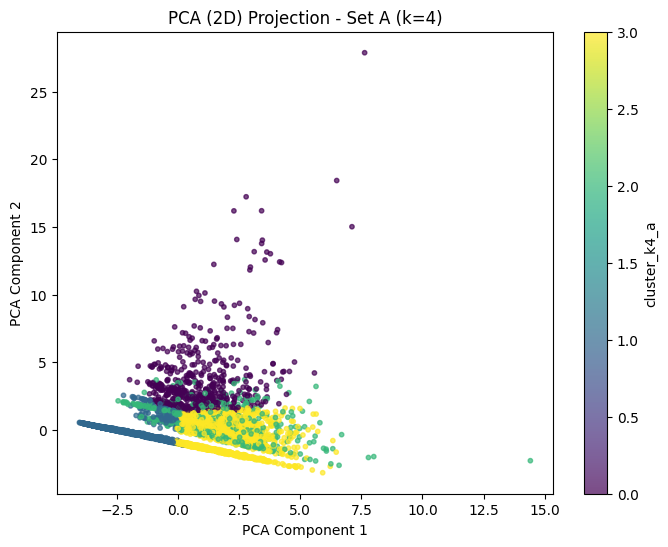

In [47]:
plt.figure(figsize=(8, 6))  # erzeugung einer figure
plt.scatter(X_a_pca[:, 0], X_a_pca[:, 1], c=user_level["cluster_k4_a"], s=10, alpha=0.7)  # scatterplot der pca-komponenten mit cluster-labels
plt.xlabel("PCA Component 1")  # beschriftung der x-achse
plt.ylabel("PCA Component 2")  # beschriftung der y-achse
plt.title("PCA (2D) Projection - Set A (k=4)")  # setzen des titels
plt.colorbar(label="cluster_k4_a")  # hinzufügen einer colorbar für cluster-labels
plt.show()  # anzeigen der grafik

In [48]:
loadings = pd.DataFrame(pca.components_.T, index=feature_set_a, columns=["PC1_loading", "PC2_loading"])  # erzeugung der loading-tabelle
loadings.sort_values("PC1_loading", ascending=False).head(10), loadings.sort_values("PC2_loading", ascending=False).head(10)  # ausgabe top-10 loadings für pc1 und pc2

(                             PC1_loading  PC2_loading
 hotel_trips_count               0.413070    -0.173299
 seats_sum                       0.407198    -0.118999
 median_page_clicks              0.405482    -0.163502
 median_session_duration_sec     0.405255    -0.161443
 checked_bags_sum                0.333312    -0.107507
 total_hotel_cost_est_usd        0.240424    -0.105132
 average_flight_discount         0.235451     0.411866
 discount_flight_proportion      0.166852     0.418976
 scaled_ADS_per_km               0.163414     0.531896
 median_hotel_rate               0.154858    -0.034473,
                             PC1_loading  PC2_loading
 scaled_ADS_per_km              0.163414     0.531896
 bargain_index                  0.104137     0.492611
 discount_flight_proportion     0.166852     0.418976
 average_flight_discount        0.235451     0.411866
 pct_cancellation_sessions      0.143206     0.091946
 median_hotel_nights            0.026491    -0.002080
 median_hotel_ra

In [49]:
from sklearn.metrics import adjusted_rand_score  # import der ari-metrik
from sklearn.cluster import KMeans  # import des kmeans-modells

seeds = [0, 1, 2, 3, 4]  # definition einer seed-liste für wiederholte fits
k_final = 4  # definition der clusteranzahl

labels_by_seed = {}  # initialisierung eines dictionaries für labels je seed

for seed in seeds:  # iteration über seeds
    model = KMeans(n_clusters=k_final, random_state=seed, n_init=10)  # initialisierung kmeans mit seed
    labels_by_seed[seed] = model.fit_predict(X_a_scaled)  # speichern der labels je seed

ari_rows = []  # initialisierung einer liste für ari-vergleichszeilen

for s1 in seeds:  # iteration über seed 1
    row = {"seed": s1}  # initialisierung einer zeile mit seed-id
    for s2 in seeds:  # iteration über seed 2
        row[f"ari_vs_{s2}"] = round(float(adjusted_rand_score(labels_by_seed[s1], labels_by_seed[s2])), 4)  # berechnung ari zwischen zwei labelings
    ari_rows.append(row)  # speichern der zeile

ari_df = pd.DataFrame(ari_rows).set_index("seed")  # erzeugung der ari-matrix als dataframe
ari_df  # ausgabe der ari-matrix

,ari_vs_0,ari_vs_1,ari_vs_2,ari_vs_3,ari_vs_4
seed,,,,,
0,1.0000,1.0000,0.9426,0.7150,0.9908
1,1.0000,1.0000,0.9426,0.7150,0.9908
2,0.9426,0.9426,1.0000,0.7445,0.9514
3,0.7150,0.7150,0.7445,1.0000,0.7208
4,0.9908,0.9908,0.9514,0.7208,1.0000


In [50]:
ari_values = ari_df.values  # extraktion der matrixwerte
mask_offdiag = ~np.eye(ari_values.shape[0], dtype=bool)  # erzeugung einer maske ohne diagonale
ari_mean_offdiag = float(ari_values[mask_offdiag].mean())  # berechnung des durchschnitts off-diagonal

ari_mean_offdiag  # ausgabe des durchschnittlichen ari-werts

0.87135

In [51]:
import os  # import der os-bibliothek
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

user_level = user_level.copy()  # erstellen einer arbeitskopie des dataframes

cluster_col = "cluster_k4_a"  # definition der cluster-label-spalte

def minmax_01(series):  # definition einer funktion zur min-max-skalierung auf 0-1
    s = pd.to_numeric(series, errors="coerce")  # konvertierung zu numeric mit coercion
    s_min = float(s.min())  # berechnung des minimums
    s_max = float(s.max())  # berechnung des maximums
    rng = float(s_max - s_min)  # berechnung der spannweite
    out = np.where(rng > 0, (s - s_min) / rng, 0.0)  # berechnung min-max-skalierung oder fallback
    return pd.Series(out, index=series.index)  # rückgabe als series

def normalize_bool_to_int(series):  # definition einer funktion zur normalisierung bool-ähnlicher werte zu int
    s = series.copy()  # erstellen einer kopie der eingangsspalte
    s = s.astype(str).str.strip().str.lower()  # normalisierung durch string-konvertierung und kleinschreibung
    true_vals = {"true", "t", "1", "yes", "y"}  # definition der wahr-werte als menge
    false_vals = {"false", "f", "0", "no", "n"}  # definition der falsch-werte als menge
    out = np.where(s.isin(true_vals), 1, np.where(s.isin(false_vals), 0, 0))  # abbildung auf 1/0 mit fallback 0
    return pd.Series(out, index=series.index)  # rückgabe als series

if "has_children" in user_level.columns:  # prüfung auf vorhandene has_children-spalte
    user_level["has_children_int"] = normalize_bool_to_int(user_level["has_children"])  # erzeugung has_children_int

user_level["seats_sum"] = pd.to_numeric(user_level["seats_sum"], errors="coerce").fillna(0.0)  # normalisierung seats_sum
user_level["checked_bags_sum"] = pd.to_numeric(user_level["checked_bags_sum"], errors="coerce").fillna(0.0)  # normalisierung checked_bags_sum

user_level["bags_per_seat"] = np.where(  # berechnung checked-bags pro sitz
    user_level["seats_sum"] > 0,  # bedingung für division
    user_level["checked_bags_sum"] / user_level["seats_sum"],  # berechnung ratio
    0.0,  # fallback bei seats_sum==0
)

norm = {}  # initialisierung eines dictionaries für normalisierte features

norm["discount_flight_proportion"] = minmax_01(user_level.get("discount_flight_proportion", 0.0))  # normalisierung discount_flight_proportion
norm["average_flight_discount"] = minmax_01(user_level.get("average_flight_discount", 0.0))  # normalisierung average_flight_discount
norm["scaled_ADS_per_km"] = minmax_01(user_level.get("scaled_ADS_per_km", 0.0))  # normalisierung scaled_ADS_per_km
norm["bargain_index"] = minmax_01(user_level.get("bargain_index", 0.0))  # normalisierung bargain_index

norm["pct_cancellation_sessions"] = minmax_01(user_level.get("pct_cancellation_sessions", 0.0))  # normalisierung pct_cancellation_sessions
norm["median_session_duration_sec"] = minmax_01(user_level.get("median_session_duration_sec", 0.0))  # normalisierung median_session_duration_sec
norm["median_page_clicks"] = minmax_01(user_level.get("median_page_clicks", 0.0))  # normalisierung median_page_clicks

norm["hotel_trips_count"] = minmax_01(user_level.get("hotel_trips_count", 0.0))  # normalisierung hotel_trips_count
norm["median_hotel_nights"] = minmax_01(user_level.get("median_hotel_nights", 0.0))  # normalisierung median_hotel_nights
norm["median_hotel_rate"] = minmax_01(user_level.get("median_hotel_rate", 0.0))  # normalisierung median_hotel_rate
norm["total_hotel_cost_est_usd"] = minmax_01(user_level.get("total_hotel_cost_est_usd", 0.0))  # normalisierung total_hotel_cost_est_usd

norm["bags_per_seat"] = minmax_01(user_level["bags_per_seat"])  # normalisierung bags_per_seat
norm["seats_sum"] = minmax_01(user_level["seats_sum"])  # normalisierung seats_sum

if "has_children_int" in user_level.columns:  # prüfung auf vorhandene has_children_int-spalte
    norm["has_children_int"] = minmax_01(user_level["has_children_int"])  # normalisierung has_children_int
else:  # fallback bei fehlender spalte
    norm["has_children_int"] = pd.Series(0.0, index=user_level.index)  # erzeugung einer 0-serie als ersatz

In [52]:
scores = pd.DataFrame(index=user_level.index)  # initialisierung eines score-dataframes

scores["exclusive_discounts"] = (  # berechnung score für exclusive_discounts
    0.35 * norm["discount_flight_proportion"] +  # gewichtung discount_flight_proportion
    0.25 * norm["average_flight_discount"] +  # gewichtung average_flight_discount
    0.20 * norm["scaled_ADS_per_km"] +  # gewichtung scaled_ADS_per_km
    0.20 * norm["bargain_index"]  # gewichtung bargain_index
)

scores["no_cancellation_fees"] = (  # berechnung score für no_cancellation_fees
    0.60 * norm["pct_cancellation_sessions"] +  # gewichtung cancellation-anteil
    0.20 * norm["median_session_duration_sec"] +  # gewichtung sessiondauer
    0.20 * norm["median_page_clicks"]  # gewichtung klicks
)

scores["free_checked_bag"] = (  # berechnung score für free_checked_bag
    0.45 * norm["bags_per_seat"] +  # gewichtung bags pro sitz
    0.30 * norm["seats_sum"] +  # gewichtung gruppen-/seat-signal
    0.25 * norm["has_children_int"]  # gewichtung kinder-indikator
)

scores["free_hotel_meal"] = (  # berechnung score für free_hotel_meal
    0.45 * norm["hotel_trips_count"] +  # gewichtung hotelhäufigkeit
    0.35 * norm["median_hotel_nights"] +  # gewichtung stay-länge
    0.20 * norm["median_hotel_rate"]  # gewichtung hotel-preisniveau
)

scores["one_night_free_hotel_with_flight"] = (  # berechnung score für 1 night free hotel with flight
    0.35 * norm["hotel_trips_count"] +  # gewichtung hotelhäufigkeit
    0.25 * norm["median_hotel_nights"] +  # gewichtung stay-länge
    0.25 * (1.0 - norm["median_hotel_rate"]) +  # gewichtung budget-orientierung über hotel-rate
    0.15 * norm["bargain_index"]  # gewichtung deal-orientierung
)

perk_order = [  # definition einer deterministischen tie-break-reihenfolge
    "no_cancellation_fees",
    "exclusive_discounts",
    "free_hotel_meal",
    "one_night_free_hotel_with_flight",
    "free_checked_bag",
]

scores = scores[perk_order]  # anordnung der score-spalten nach tie-break-reihenfolge

assigned_perk = scores.idxmax(axis=1)  # auswahl des perks mit maximalem score je user

user_level = user_level.copy()  # erstellen einer arbeitskopie des user-level-dataframes
user_level["assigned_perk"] = assigned_perk  # speichern des zugewiesenen perks

In [53]:
perk_counts = user_level["assigned_perk"].value_counts()  # zählung der perk-zuweisungen
perk_pct = (perk_counts / perk_counts.sum() * 100).round(2)  # berechnung der anteile in prozent

perk_distribution = pd.DataFrame({  # erzeugung einer perk-verteilungstabelle
    "count": perk_counts,  # definition der counts
    "pct": perk_pct,  # definition der prozentanteile
})  # abschließen der tabelle

perk_distribution  # ausgabe der perk-verteilung

perk_by_cluster = pd.crosstab(user_level[cluster_col], user_level["assigned_perk"], normalize="index").round(3)  # berechnung der perk-anteile je cluster
perk_by_cluster  # ausgabe der cluster-perk-kreuztabelle

assigned_perk,exclusive_discounts,free_checked_bag,free_hotel_meal,no_cancellation_fees,one_night_free_hotel_with_flight
cluster_k4_a,,,,,
0,0.499,0.140,0.018,0.002,0.341
1,0.005,0.189,0.059,0.000,0.746
2,0.109,0.200,0.029,0.323,0.339
3,0.001,0.200,0.060,0.000,0.738


In [54]:
import pandas as pd  # import der pandas-bibliothek

OUTPUT_PERK_PATH = f"{PROCESSED_DIR}/user_perk_assignment_k4a.csv"  # definition des output-dateipfads

base_cols = ["user_id", cluster_col, "assigned_perk"]  # definition der basis-spalten für output

user_level_out = user_level[base_cols].copy()  # erzeugung einer output-tabelle mit basis-spalten

scores_aligned = scores.copy()  # erstellen einer arbeitskopie der scores-tabelle
scores_aligned = scores_aligned.reset_index(drop=True)  # zurücksetzen des index für positionsbasierten merge
user_level_out = user_level_out.reset_index(drop=True)  # zurücksetzen des index für positionsbasierten merge

user_level_out = pd.concat([user_level_out, scores_aligned], axis=1)  # hinzufügen der score-spalten zur output-tabelle

user_level_out.to_csv(OUTPUT_PERK_PATH, index=False)  # speichern der output-tabelle als csv
OUTPUT_PERK_PATH  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/user_perk_assignment_k4a.csv'

In [55]:
score_cols = list(scores.columns)  # definition der score-spaltenliste

score_profile = user_level_out.groupby(cluster_col)[score_cols].median()  # berechnung der median-scores je cluster
score_profile  # ausgabe der score-profile

,no_cancellation_fees,exclusive_discounts,free_hotel_meal,one_night_free_hotel_with_flight,free_checked_bag
cluster_k4_a,,,,,
0,0.040463,0.347295,0.241147,0.329711,0.170000
1,0.030343,0.000000,0.205612,0.298268,0.160000
2,0.357866,0.187533,0.280132,0.354485,0.176429
3,0.064037,0.000000,0.312540,0.385244,0.192500


In [56]:
perk_counts = user_level["assigned_perk"].value_counts()  # zählung der perk-zuweisungen
perk_pct = (perk_counts / perk_counts.sum() * 100).round(2)  # berechnung der anteile in prozent

perk_distribution = pd.DataFrame({  # erzeugung einer perk-verteilungstabelle
    "count": perk_counts,  # definition der counts
    "pct": perk_pct,  # definition der prozentanteile
})  # abschließen der tabelle

perk_distribution  # ausgabe der perk-verteilung

,count,pct
assigned_perk,,
one_night_free_hotel_with_flight,4022,67.06
free_checked_bag,1140,19.01
exclusive_discounts,335,5.59
free_hotel_meal,319,5.32
no_cancellation_fees,182,3.03


In [57]:
sample_cols = [  # definition der spalten für plausibilitätscheck
    "user_id",
    cluster_col,
    "assigned_perk",
    "hotel_trips_count",
    "median_hotel_nights",
    "median_hotel_rate",
    "total_hotel_cost_est_usd",
    "discount_flight_proportion",
    "average_flight_discount",
    "scaled_ADS_per_km",
    "bargain_index",
    "pct_cancellation_sessions",
    "median_session_duration_sec",
    "median_page_clicks",
    "seats_sum",
    "checked_bags_sum",
]  # abschließen der spaltenliste

sample_cols = [c for c in sample_cols if c in user_level.columns]  # filterung auf vorhandene spalten

samples = (  # initialisierung der sample-auswahl
    user_level[sample_cols]  # auswahl der relevanten spalten
    .groupby("assigned_perk", group_keys=False)  # gruppierung nach assigned_perk
    .apply(lambda df: df.sample(n=min(5, len(df)), random_state=42))  # ziehen von bis zu 5 beispielen je perk
)  # abschließen der sample-auswahl

samples  # ausgabe der beispiel-user je perk

/tmp/ipykernel_164/1932943615.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.sample(n=min(5, len(df)), random_state=42))  # ziehen von bis zu 5 beispielen je perk


,user_id,cluster_k4_a,assigned_perk,hotel_trips_count,median_hotel_nights,median_hotel_rate,total_hotel_cost_est_usd,discount_flight_proportion,average_flight_discount,scaled_ADS_per_km,bargain_index,pct_cancellation_sessions,median_session_duration_sec,median_page_clicks,seats_sum,checked_bags_sum
479,486261,0,exclusive_discounts,2,4.5,46.00,714.0,1.000000,0.050,0.166615,0.008331,0.00,51.0,7.0,3.0,0.0
2174,526676,2,exclusive_discounts,2,2.5,124.50,435.0,0.666667,0.250,0.034232,0.005705,12.50,76.0,10.0,3.0,1.0
1483,516841,0,exclusive_discounts,1,3.0,443.00,1329.0,1.000000,0.150,0.174764,0.026215,0.00,65.0,8.5,1.0,1.0
4165,565275,0,exclusive_discounts,1,2.0,109.00,218.0,1.000000,0.100,0.100015,0.010002,0.00,79.5,10.5,1.0,1.0
1119,512447,0,exclusive_discounts,2,7.0,98.50,1656.0,1.000000,0.250,0.708918,0.177230,0.00,58.0,7.5,3.0,1.0
4200,565949,3,free_checked_bag,4,3.5,156.00,3719.0,0.333333,0.150,0.038447,0.001922,0.00,124.0,16.5,3.0,3.0
4820,586251,2,free_checked_bag,2,6.5,109.50,758.0,0.333333,0.000,0.000000,0.000000,12.50,162.5,22.0,3.0,2.0
1544,517819,1,free_checked_bag,1,3.0,200.00,600.0,0.000000,0.000,0.000000,0.000000,0.00,107.0,14.0,1.0,2.0
5507,627158,1,free_checked_bag,1,1.0,142.00,142.0,0.000000,0.000,0.000000,0.000000,0.00,64.0,8.5,3.0,2.0
1716,520152,3,free_checked_bag,4,3.5,203.50,2734.0,0.333333,0.100,0.013745,0.000458,0.00,136.0,18.0,3.0,3.0


In [58]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

scores_gated = scores.copy()  # erstellen einer arbeitskopie der score-tabelle

hotel_trips = pd.to_numeric(user_level.get("hotel_trips_count", 0), errors="coerce").fillna(0)  # laden hotel_trips_count als numeric
flight_trips = pd.to_numeric(user_level.get("flight_trips_count", 0), errors="coerce").fillna(0)  # laden flight_trips_count als numeric
seats_sum = pd.to_numeric(user_level.get("seats_sum", 0), errors="coerce").fillna(0)  # laden seats_sum als numeric
cancel_pct = pd.to_numeric(user_level.get("pct_cancellation_sessions", 0), errors="coerce").fillna(0)  # laden pct_cancellation_sessions als numeric

mask_has_hotel = hotel_trips.gt(0)  # indikator für user mit hotel-trips
mask_has_flight = flight_trips.gt(0)  # indikator für user mit flight-trips
mask_has_seats = seats_sum.gt(0)  # indikator für user mit seats
mask_has_cancel = cancel_pct.gt(0)  # indikator für user mit cancellations

scores_gated.loc[~mask_has_hotel, "free_hotel_meal"] = 0.0  # deaktivierung free_hotel_meal ohne hotel-trips
scores_gated.loc[~mask_has_hotel, "one_night_free_hotel_with_flight"] = 0.0  # deaktivierung 1-night ohne hotel-trips

scores_gated.loc[~mask_has_flight, "exclusive_discounts"] = 0.0  # deaktivierung exclusive_discounts ohne flight-trips
scores_gated.loc[~mask_has_flight, "free_checked_bag"] = 0.0  # deaktivierung free_checked_bag ohne flight-trips

scores_gated.loc[~mask_has_seats, "free_checked_bag"] = 0.0  # deaktivierung free_checked_bag ohne seats

scores_gated.loc[~mask_has_cancel, "no_cancellation_fees"] = 0.0  # deaktivierung no_cancellation_fees ohne cancellations

user_level = user_level.copy()  # erstellen einer arbeitskopie des dataframes
user_level["assigned_perk_gated"] = scores_gated.idxmax(axis=1)  # zuweisung des perks mit maximalem score nach gating

dist_old = user_level["assigned_perk"].value_counts(normalize=True).mul(100).round(2)  # berechnung prozentverteilung alt
dist_new = user_level["assigned_perk_gated"].value_counts(normalize=True).mul(100).round(2)  # berechnung prozentverteilung neu

pd.DataFrame({"pct_old": dist_old, "pct_new": dist_new}).fillna(0).sort_values("pct_new", ascending=False)  # vergleich alt vs neu

,pct_old,pct_new
one_night_free_hotel_with_flight,67.06,58.74
free_checked_bag,19.01,19.66
no_cancellation_fees,3.03,10.64
exclusive_discounts,5.59,5.60
free_hotel_meal,5.32,5.37


In [59]:
perk_by_cluster_gated = pd.crosstab(  # berechnung der perk-anteile je cluster (gated)
    user_level[cluster_col],  # zeilen = cluster
    user_level["assigned_perk_gated"],  # spalten = perk (gated)
    normalize="index",  # normalisierung pro cluster
).round(3)  # rundung auf 3 stellen

perk_by_cluster_gated  # ausgabe der gated cluster-perk-kreuztabelle

assigned_perk_gated,exclusive_discounts,free_checked_bag,free_hotel_meal,no_cancellation_fees,one_night_free_hotel_with_flight
cluster_k4_a,,,,,
0,0.499,0.140,0.018,0.002,0.341
1,0.006,0.203,0.060,0.166,0.565
2,0.109,0.200,0.029,0.323,0.339
3,0.001,0.200,0.060,0.000,0.738


In [60]:
OUTPUT_PERK_FINAL_PATH = f"{PROCESSED_DIR}/user_perk_assignment_final_k4a.csv"  # definition des output-dateipfads

user_level = user_level.copy()  # erstellen einer arbeitskopie des dataframes
user_level["assigned_perk_final"] = user_level["assigned_perk_gated"]  # setzen der finalen perk-zuweisung

final_cols = [  # definition der finalen output-spalten
    "user_id",
    cluster_col,
    "assigned_perk_final",
]  # abschließen der spaltenliste

user_level_final_out = user_level[final_cols].copy()  # erzeugung der finalen output-tabelle
user_level_final_out.to_csv(OUTPUT_PERK_FINAL_PATH, index=False)  # speichern der finalen output-tabelle als csv

OUTPUT_PERK_FINAL_PATH  # ausgabe des speicherpfads

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/user_perk_assignment_final_k4a.csv'

In [61]:
import pandas as pd  # import der pandas-bibliothek

cluster_sizes = user_level[cluster_col].value_counts().sort_index()  # berechnung clustergrößen
cluster_pct = (cluster_sizes / cluster_sizes.sum() * 100).round(2)  # berechnung cluster-anteile in prozent

perk_cluster_pct = (perk_by_cluster_gated * 100).round(1)  # umrechnung der perk-anteile in prozent

top_perk = perk_by_cluster_gated.idxmax(axis=1)  # ermittlung des dominanten perks je cluster
top_perk_share = (perk_by_cluster_gated.max(axis=1) * 100).round(1)  # ermittlung des anteils des dominanten perks

cluster_perk_summary = perk_cluster_pct.copy()  # erstellen einer arbeitskopie der perk-tabelle
cluster_perk_summary.insert(0, "cluster_pct", cluster_pct)  # einfügen cluster-anteil
cluster_perk_summary.insert(0, "cluster_size", cluster_sizes)  # einfügen cluster-größe
cluster_perk_summary.insert(2, "top_perk", top_perk)  # einfügen dominanter perk
cluster_perk_summary.insert(3, "top_perk_pct", top_perk_share)  # einfügen anteil dominanter perk

cluster_perk_summary  # ausgabe der summary-tabelle

assigned_perk_gated,cluster_size,cluster_pct,top_perk,top_perk_pct,exclusive_discounts,free_checked_bag,free_hotel_meal,no_cancellation_fees,one_night_free_hotel_with_flight
cluster_k4_a,,,,,,,,,
0,513,8.55,exclusive_discounts,49.9,49.9,14.0,1.8,0.2,34.1
1,2752,45.88,one_night_free_hotel_with_flight,56.5,0.6,20.3,6.0,16.6,56.5
2,560,9.34,one_night_free_hotel_with_flight,33.9,10.9,20.0,2.9,32.3,33.9
3,2173,36.23,one_night_free_hotel_with_flight,73.8,0.1,20.0,6.0,0.0,73.8


In [62]:
import os  # import der os-bibliothek
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek
import matplotlib.pyplot as plt  # import der plotting-bibliothek

FIG_DIR = f"{PROCESSED_DIR}/figures"  # definition des figure-ordners
os.makedirs(FIG_DIR, exist_ok=True)  # erstellen des figure-ordners falls nicht vorhanden

cluster_col = "cluster_k4_a"  # definition der cluster-spalte

perk_col = "assigned_perk_final" if "assigned_perk_final" in user_level.columns else "assigned_perk_gated"  # auswahl der perk-spalte

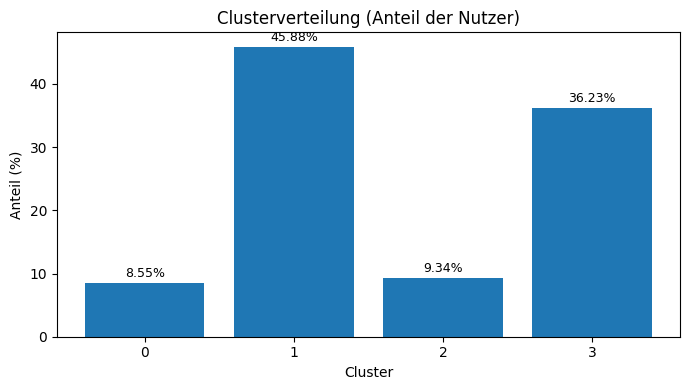

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/figures/cluster_distribution.png'

In [63]:
cluster_sizes = user_level[cluster_col].value_counts().sort_index()  # berechnung clustergrößen
cluster_pct = (cluster_sizes / cluster_sizes.sum() * 100).round(2)  # berechnung cluster-anteile in prozent

fig = plt.figure(figsize=(7, 4))  # erzeugung einer figure
ax = plt.gca()  # auswahl der aktuellen achse

ax.bar(cluster_sizes.index.astype(str), cluster_pct.values)  # zeichnen des balkendiagramms
ax.set_title("Clusterverteilung (Anteil der Nutzer)")  # setzen des titels
ax.set_xlabel("Cluster")  # beschriftung der x-achse
ax.set_ylabel("Anteil (%)")  # beschriftung der y-achse

for i, v in enumerate(cluster_pct.values):  # iteration über balkenwerte
    ax.text(i, v + 0.5, f"{v}%", ha="center", va="bottom", fontsize=9)  # hinzufügen von labels

plt.tight_layout()  # optimierung des layouts

path_cluster_dist = f"{FIG_DIR}/cluster_distribution.png"  # definition des speicherpfads
plt.savefig(path_cluster_dist, dpi=200)  # speichern der grafik
plt.show()  # anzeigen der grafik

path_cluster_dist  # ausgabe des speicherpfads

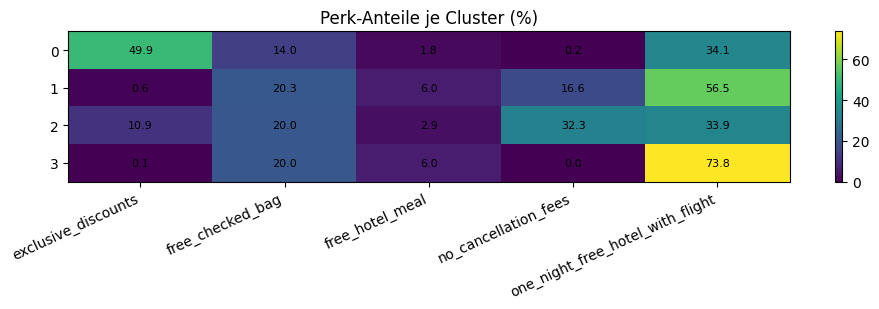

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/figures/perk_by_cluster_heatmap.png'

In [64]:
perk_by_cluster_plot = perk_by_cluster_gated.copy()  # kopie der perk-by-cluster-tabelle
perk_by_cluster_plot = (perk_by_cluster_plot * 100).round(1)  # umrechnung in prozent

fig = plt.figure(figsize=(10, 3.2))  # erzeugung einer figure
ax = plt.gca()  # auswahl der aktuellen achse

im = ax.imshow(perk_by_cluster_plot.values, aspect="auto")  # erzeugung einer heatmap

ax.set_title("Perk-Anteile je Cluster (%)")  # setzen des titels
ax.set_yticks(range(len(perk_by_cluster_plot.index)))  # setzen der y-ticks
ax.set_yticklabels(perk_by_cluster_plot.index.astype(str))  # setzen der y-labels
ax.set_xticks(range(len(perk_by_cluster_plot.columns)))  # setzen der x-ticks
ax.set_xticklabels(perk_by_cluster_plot.columns, rotation=25, ha="right")  # setzen der x-labels

for i in range(perk_by_cluster_plot.shape[0]):  # iteration über zeilen
    for j in range(perk_by_cluster_plot.shape[1]):  # iteration über spalten
        ax.text(j, i, f"{perk_by_cluster_plot.iat[i, j]:.1f}", ha="center", va="center", fontsize=8)  # eintragen der werte

plt.colorbar(im, ax=ax)  # hinzufügen einer colorbar
plt.tight_layout()  # optimierung des layouts

path_perk_cluster = f"{FIG_DIR}/perk_by_cluster_heatmap.png"  # definition des speicherpfads
plt.savefig(path_perk_cluster, dpi=200)  # speichern der grafik
plt.show()  # anzeigen der grafik

path_perk_cluster  # ausgabe des speicherpfads

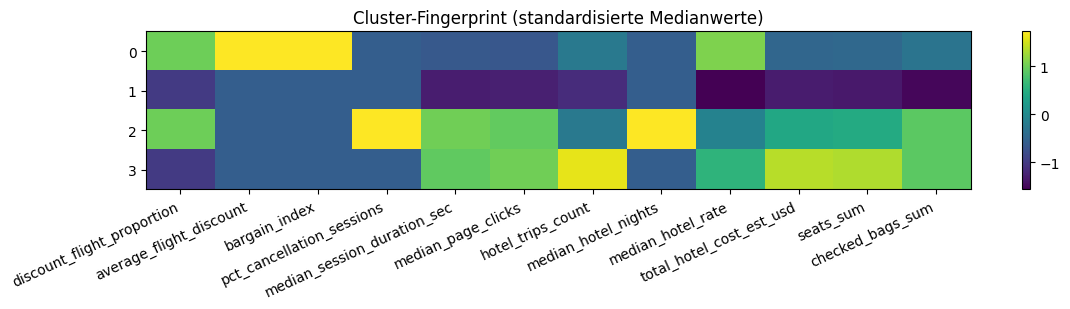

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/figures/cluster_fingerprint_heatmap.png'

In [65]:
fingerprint_features = [  # definition der feature-liste für fingerprint
    "discount_flight_proportion",
    "average_flight_discount",
    "bargain_index",
    "pct_cancellation_sessions",
    "median_session_duration_sec",
    "median_page_clicks",
    "hotel_trips_count",
    "median_hotel_nights",
    "median_hotel_rate",
    "total_hotel_cost_est_usd",
    "seats_sum",
    "checked_bags_sum",
]  # abschließen der feature-liste

fingerprint_features = [c for c in fingerprint_features if c in user_level.columns]  # filterung auf vorhandene spalten

cluster_medians = user_level.groupby(cluster_col)[fingerprint_features].median()  # berechnung der medianwerte je cluster

cluster_medians_scaled = cluster_medians.copy()  # kopie der median-tabelle
cluster_medians_scaled = (cluster_medians_scaled - cluster_medians_scaled.mean()) / cluster_medians_scaled.std(ddof=0)  # standardisierung je feature
cluster_medians_scaled = cluster_medians_scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)  # ersatz von inf/nan durch 0

fig = plt.figure(figsize=(12, 3.2))  # erzeugung einer figure
ax = plt.gca()  # auswahl der aktuellen achse

im = ax.imshow(cluster_medians_scaled.values, aspect="auto")  # erzeugung der heatmap

ax.set_title("Cluster-Fingerprint (standardisierte Medianwerte)")  # setzen des titels
ax.set_yticks(range(len(cluster_medians_scaled.index)))  # setzen der y-ticks
ax.set_yticklabels(cluster_medians_scaled.index.astype(str))  # setzen der y-labels
ax.set_xticks(range(len(cluster_medians_scaled.columns)))  # setzen der x-ticks
ax.set_xticklabels(cluster_medians_scaled.columns, rotation=25, ha="right")  # setzen der x-labels

plt.colorbar(im, ax=ax)  # hinzufügen einer colorbar
plt.tight_layout()  # optimierung des layouts

path_fingerprint = f"{FIG_DIR}/cluster_fingerprint_heatmap.png"  # definition des speicherpfads
plt.savefig(path_fingerprint, dpi=200)  # speichern der grafik
plt.show()  # anzeigen der grafik

path_fingerprint  # ausgabe des speicherpfads

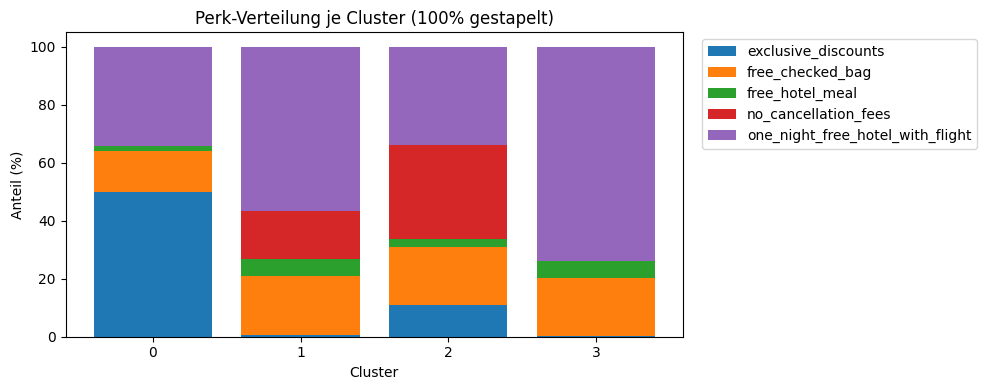

'/content/drive/MyDrive/TravelTide_MasteryProject/processed/figures/perk_by_cluster_stacked.png'

In [66]:
import matplotlib.pyplot as plt  # import der plotting-bibliothek

perk_col = "assigned_perk_final" if "assigned_perk_final" in user_level.columns else "assigned_perk_gated"  # auswahl der perk-spalte

perk_by_cluster_gated = pd.crosstab(  # berechnung perk-anteile je cluster
    user_level[cluster_col],  # zeilen = cluster
    user_level[perk_col],  # spalten = perk
    normalize="index",  # normalisierung pro cluster
).round(4)  # rundung für stabile darstellung

perk_pct = (perk_by_cluster_gated * 100).round(1)  # umrechnung in prozentwerte

plot_df = perk_pct.sort_index()  # sortierung nach cluster-index

plt.figure(figsize=(10, 4))  # erzeugung einer figure

bottom = np.zeros(len(plot_df))  # initialisierung der bottom-werte für stacking
x = np.arange(len(plot_df.index))  # erzeugung der x-positionen

for col in plot_df.columns:  # iteration über perk-spalten
    plt.bar(x, plot_df[col].values, bottom=bottom, label=col)  # zeichnen eines stacked bar segments
    bottom = bottom + plot_df[col].values  # update der bottom-werte

plt.xticks(x, plot_df.index.astype(str))  # setzen der x-achsen labels
plt.title("Perk-Verteilung je Cluster (100% gestapelt)")  # setzen des titels
plt.xlabel("Cluster")  # beschriftung der x-achse
plt.ylabel("Anteil (%)")  # beschriftung der y-achse
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")  # platzierung der legende außerhalb
plt.tight_layout()  # optimierung des layouts

path_perk_stacked = f"{FIG_DIR}/perk_by_cluster_stacked.png"  # definition des speicherpfads
plt.savefig(path_perk_stacked, dpi=200)  # speichern der grafik
plt.show()  # anzeigen der grafik

path_perk_stacked  # ausgabe des speicherpfads

In [67]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

persona_cols = [  # definition der persona-attributliste
    "sessions_count",
    "median_session_duration_sec",
    "median_page_clicks",
    "pct_cancellation_sessions",
    "flight_trips_count",
    "discount_flight_proportion",
    "average_flight_discount",
    "bargain_index",
    "seats_sum",
    "checked_bags_sum",
    "hotel_trips_count",
    "median_hotel_nights",
    "median_hotel_rate",
    "total_hotel_cost_est_usd",
]  # abschließen der attributliste

persona_cols = [c for c in persona_cols if c in user_level.columns]  # filterung auf vorhandene spalten

cluster_sizes = user_level[cluster_col].value_counts().sort_index()  # berechnung clustergrößen
cluster_pct = (cluster_sizes / cluster_sizes.sum() * 100).round(2)  # berechnung cluster-anteile in prozent

perk_mix = pd.crosstab(user_level[cluster_col], user_level[perk_col], normalize="index")  # berechnung perk-mix je cluster
top_perk = perk_mix.idxmax(axis=1)  # ermittlung top-perk je cluster
top_perk_pct = (perk_mix.max(axis=1) * 100).round(1)  # ermittlung top-perk-anteil je cluster

cluster_median = user_level.groupby(cluster_col)[persona_cols].median().round(2)  # berechnung medianwerte je cluster
persona_table = cluster_median.copy()  # kopie der median-tabelle

persona_table.insert(0, "cluster_size", cluster_sizes)  # einfügen clustergröße
persona_table.insert(1, "cluster_pct", cluster_pct)  # einfügen cluster-anteil
persona_table.insert(2, "top_perk", top_perk)  # einfügen top-perk
persona_table.insert(3, "top_perk_pct", top_perk_pct)  # einfügen top-perk-anteil

def perk_reason(row):  # definition einer funktion zur textbegründung
    p = row["top_perk"]  # auslesen top-perk
    if p == "exclusive_discounts":  # bedingung für discount-perk
        return "hohe discount- und bargain-signale im vergleich zu anderen clustern"  # rückgabe kommentartext
    if p == "no_cancellation_fees":  # bedingung für cancellation-perk
        return "erhöhte cancellation-anteile sowie längere sessions und mehr klicks"  # rückgabe kommentartext
    if p == "free_checked_bag":  # bedingung für bag-perk
        return "erhöhte seats- und baggage-werte als indikator für gruppen/gepäckbedarf"  # rückgabe kommentartext
    if p == "free_hotel_meal":  # bedingung für meal-perk
        return "höhere hotel-intensität und tendenziell höheres hotel-preisniveau"  # rückgabe kommentartext
    if p == "one_night_free_hotel_with_flight":  # bedingung für free-night-perk
        return "value-signal im hotelkontext sowie deal-orientierung im vergleich zu anderen clustern"  # rückgabe kommentartext
    return "kein kommentar verfügbar"  # fallback text

persona_table["perk_rationale"] = persona_table.apply(perk_reason, axis=1)  # erzeugung der begründungsspalte

OUTPUT_PERSONA_PATH = f"{PROCESSED_DIR}/persona_table_cluster_medians.csv"  # definition des output-dateipfads
persona_table.to_csv(OUTPUT_PERSONA_PATH, index=True)  # speichern der persona-tabelle als csv

persona_table  # ausgabe der persona-tabelle

,cluster_size,cluster_pct,top_perk,top_perk_pct,sessions_count,median_session_duration_sec,median_page_clicks,pct_cancellation_sessions,flight_trips_count,discount_flight_proportion,average_flight_discount,bargain_index,seats_sum,checked_bags_sum,hotel_trips_count,median_hotel_nights,median_hotel_rate,total_hotel_cost_est_usd,perk_rationale
cluster_k4_a,,,,,,,,,,,,,,,,,,,
0,513,8.55,exclusive_discounts,49.9,8.0,89.00,12.00,0.0,2.0,0.5,0.18,0.01,2.0,1.0,2.0,2.5,160.0,1110.0,hohe discount- und bargain-signale im vergleic...
1,2752,45.88,one_night_free_hotel_with_flight,56.5,8.0,72.50,10.00,0.0,1.0,0.0,0.00,0.00,1.0,0.0,1.0,2.5,129.0,658.0,value-signal im hotelkontext sowie deal-orient...
2,560,9.34,one_night_free_hotel_with_flight,33.9,8.0,131.25,17.25,12.5,3.0,0.5,0.00,0.00,3.0,2.0,2.0,3.0,146.0,1594.0,value-signal im hotelkontext sowie deal-orient...
3,2173,36.23,one_night_free_hotel_with_flight,73.8,8.0,129.00,17.50,0.0,4.0,0.0,0.00,0.00,4.0,2.0,4.0,2.5,154.0,2113.0,value-signal im hotelkontext sowie deal-orient...


In [68]:
import pandas as pd  # import der pandas-bibliothek
import numpy as np  # import der numpy-bibliothek

cluster_sizes = user_level[cluster_col].value_counts().sort_index()  # berechnung clustergrößen
cluster_pct = (cluster_sizes / cluster_sizes.sum() * 100).round(2)  # berechnung cluster-anteile in prozent

perk_mix = pd.crosstab(user_level[cluster_col], user_level[perk_col], normalize="index")  # perk-anteile je cluster

top_perk = perk_mix.idxmax(axis=1)  # ermittlung top-perk je cluster
top_perk_pct = (perk_mix.max(axis=1) * 100).round(1)  # ermittlung top-perk-anteil

second_perk = perk_mix.apply(lambda r: r.sort_values(ascending=False).index[1], axis=1)  # ermittlung second-perk je cluster
second_perk_pct = (perk_mix.apply(lambda r: r.sort_values(ascending=False).iloc[1], axis=1) * 100).round(1)  # ermittlung second-perk-anteil

persona_cols_compact = [  # definition der kompakt-spalten
    "median_session_duration_sec",
    "median_page_clicks",
    "pct_cancellation_sessions",
    "discount_flight_proportion",
    "average_flight_discount",
    "bargain_index",
    "hotel_trips_count",
    "median_hotel_rate",
    "seats_sum",
    "checked_bags_sum",
]  # abschließen der spaltenliste

persona_cols_compact = [c for c in persona_cols_compact if c in user_level.columns]  # filterung auf vorhandene spalten

cluster_median = user_level.groupby(cluster_col)[persona_cols_compact].median().round(2)  # medianwerte je cluster

persona_compact = cluster_median.copy()  # kopie der median-tabelle
persona_compact.insert(0, "cluster_size", cluster_sizes)  # einfügen clustergröße
persona_compact.insert(1, "cluster_pct", cluster_pct)  # einfügen cluster-anteil
persona_compact.insert(2, "top_perk", top_perk)  # einfügen top-perk
persona_compact.insert(3, "top_perk_pct", top_perk_pct)  # einfügen top-perk-anteil
persona_compact.insert(4, "second_perk", second_perk)  # einfügen second-perk
persona_compact.insert(5, "second_perk_pct", second_perk_pct)  # einfügen second-perk-anteil

rename_map = {  # definition sprechender spaltennamen für slides
    "median_session_duration_sec": "session_dur_med_s",
    "median_page_clicks": "clicks_med",
    "pct_cancellation_sessions": "cancel_pct",
    "discount_flight_proportion": "disc_flight_pct",
    "average_flight_discount": "disc_avg",
    "bargain_index": "bargain_idx",
    "hotel_trips_count": "hotel_trips",
    "median_hotel_rate": "hotel_rate_med",
    "seats_sum": "seats_sum",
    "checked_bags_sum": "bags_sum",
}  # abschließen rename-map

persona_compact = persona_compact.rename(columns=rename_map)  # umbenennung der spalten

persona_compact  # ausgabe der kompakten persona-tabelle

,cluster_size,cluster_pct,top_perk,top_perk_pct,second_perk,second_perk_pct,session_dur_med_s,clicks_med,cancel_pct,disc_flight_pct,disc_avg,bargain_idx,hotel_trips,hotel_rate_med,seats_sum,bags_sum
cluster_k4_a,,,,,,,,,,,,,,,,
0,513,8.55,exclusive_discounts,49.9,one_night_free_hotel_with_flight,34.1,89.00,12.00,0.0,0.5,0.18,0.01,2.0,160.0,2.0,1.0
1,2752,45.88,one_night_free_hotel_with_flight,56.5,free_checked_bag,20.3,72.50,10.00,0.0,0.0,0.00,0.00,1.0,129.0,1.0,0.0
2,560,9.34,one_night_free_hotel_with_flight,33.9,no_cancellation_fees,32.3,131.25,17.25,12.5,0.5,0.00,0.00,2.0,146.0,3.0,2.0
3,2173,36.23,one_night_free_hotel_with_flight,73.8,free_checked_bag,20.0,129.00,17.50,0.0,0.0,0.00,0.00,4.0,154.0,4.0,2.0
